# Recall Analysis

This Notebook Aims at Analysing the Data from Recall Experiments. Computing Various Data Features anbd then Making Analysis out of it:





### Parameters 

In [1]:
### Imports
import matplotlib.pyplot as plt



### Parameters and Globals
CLASSN = 4                       # Number of MW Discrete Classess
DATAFOLDER = "data_second"       # Data Folder for experiment
LABELING = False                 # Labeling Mode
CLASSESS =  {1:"Focus",          # Classess Dictionairy t understand what means what
             2:"Task-Related Thoughts", 
             3: "Mind Wandering",
             4: "Mind Wandering"}

VIZFOLDER = f"FExtraction_{CLASSN}"

### Load Data

This is a part to load the data-frames of Previous Data and analyses as well as all the other important things

also for labeling if it is necessery 

In [2]:
####    Load Necessery Variables and Paths:
import os 
from storyTools import loadStory,splitStoryEntity,reLabel
import pandas as pd
import numpy as np 

### General Working, Data, and Saving Path:
workingDir = os.getcwd();                                 # Current Folder
path = os.path.split(workingDir)[0] + "\\" + DATAFOLDER   # Data path
savePathRecall = os.path.join(workingDir,'Recalls')       # Save Path for Recall results
if os.path.isdir(savePathRecall) == 0:
    os.makedirs(savePathRecall) # Create a directory for recall results

subjects = [f for f in os.listdir(path) if  not os.path.isfile(os.path.join(path, f))]  # get all the filenames


### Load Sample Data:
text_file =  open(os.path.join(savePathRecall,"ADNA2507",'recall_JANEK_12.txt'), "r+",encoding="utf-8")
fff = text_file.readlines()[0]


### Get Polish Stopwords:
with open(r"C:\Users\barak\Documents\Python_Scripts\CoproraTools\polish.stopwords.txt", encoding="utf-8") as f:
    polish_stopwords = set(line.strip().lower() for line in f if line.strip())


### Load Previous Excel File with Data:
dfData = pd.read_excel(os.path.join(savePathRecall,"recalls.xlsx"))


### Create other Data Frames
if not os.path.isfile(os.path.join(savePathRecall,"recallsAnalysis.xlsx")):
    dfAnalysis = dfData[['Subject','Fragment','Attention','utt_leng']] # Data Frame for Analysis


### Change Classess for a 2 way classification:
#### RE-Teaching on Binary Classification: 
if CLASSN == 2:
    dfData = reLabel(dfData,renameDict={1:1,1:2,3:3,3:4})
    dfData = reLabel(dfData,renameDict={1:1,2:3})
    CLASSESS =  {1:"Focus", 2:"Mind Wandering"}




c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
From c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\tf_keras\src\losses.py:2976: The name tf.losses.sparse_softmax_cross_entropy is deprecated. Please use tf.compat.v1.losses.sparse_softmax_cross_entropy instead.



## Preprocessing 

This Part of Code Gathers Data and Functions that are Paramount for Analysis

Here we preprocess our data so it would be clean for our future Analsis and Teaching: 
0. Create Labels - (Optional)
1. Loading ALL Recall Texts - Gathering all Corpus Data
2. Loading All Stories
3. Making Morphological Entities extraction from Both Stories and Recalls

#### Create Labels: (Optional)

Here we Label our Data based on 4 classess - it is done only ones




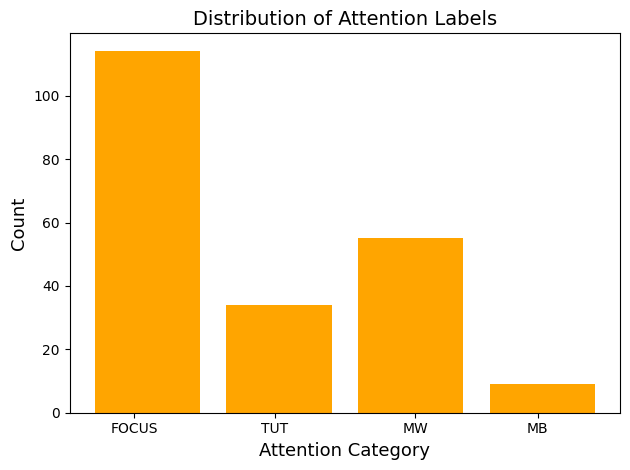

          count      mean       std  min  25%  50%  75%  max   1   2   3  4
Subject                                                                    
ADNA2507   40.0  1.375000  0.740322  1.0  1.0  1.0  1.0  3.0  31   3   6  0
ANLU2607   40.0  1.725000  0.933356  1.0  1.0  1.0  2.0  4.0  22   9   7  2
JUBE2907   17.0  1.941176  1.197424  1.0  1.0  1.0  3.0  4.0  10   0   5  2
MANI2607   40.0  1.975000  0.800240  1.0  1.0  2.0  3.0  3.0  13  15  12  0
NIZA2907   40.0  2.150000  1.001281  1.0  1.0  2.0  3.0  4.0  15   6  17  2
PIKR2907   35.0  1.742857  1.093910  1.0  1.0  1.0  3.0  4.0  23   1   8  3


,count_x,mean_x,std_x,min_x,25%_x,50%_x,75%_x,max_x,count_y,mean_y,std_y,min_y,25%_y,50%_y,75%_y,max_y,1,2,3,4
Subject,,,,,,,,,,,,,,,,,,,,
ADNA2507,40.0,161.800000,41.159602,104.0,126.50,163.5,189.25,298.0,40.0,1.375000,0.740322,1.0,1.0,1.0,1.0,3.0,31,3,6,0
ANLU2607,40.0,175.275000,66.551691,44.0,132.00,178.0,227.50,311.0,40.0,1.725000,0.933356,1.0,1.0,1.0,2.0,4.0,22,9,7,2
JUBE2907,17.0,40.058824,7.453779,30.0,33.00,40.0,43.00,57.0,17.0,1.941176,1.197424,1.0,1.0,1.0,3.0,4.0,10,0,5,2
MANI2607,40.0,167.325000,59.800260,62.0,123.50,153.5,207.75,275.0,40.0,1.975000,0.800240,1.0,1.0,2.0,3.0,3.0,13,15,12,0
NIZA2907,40.0,327.275000,108.052453,71.0,253.25,349.0,406.25,530.0,40.0,2.150000,1.001281,1.0,1.0,2.0,3.0,4.0,15,6,17,2
PIKR2907,35.0,124.285714,63.871918,43.0,69.50,111.0,160.00,328.0,35.0,1.742857,1.093910,1.0,1.0,1.0,3.0,4.0,23,1,8,3


In [3]:
if LABELING:

    subjR = os.listdir(savePathRecall)

    from IPython.display import clear_output
    answer = []
    answDict = {}


    answrScheme = {v: k for k, v in CLASSESS.items()}

    subjList     = []
    fragmentList = []
    rawCorpus    = []

    for s in subjR:
        textfiles = [f for f in os.listdir(os.path.join(savePathRecall, s)) if f.endswith('.txt') and 'recall_' in f[:7] and "KASIA" not in f]
        answDict[s] = []
        
        for t in textfiles:
            text_file =  open(os.path.join(savePathRecall,s,t), "r+",encoding="utf-8")
            fragmentList.append(os.path.splitext(t)[0])
            subjList.append(s)
            for line in text_file: # One Text - One Line: Always! - thats why it worrks although it looks INCREDIBELY SKETCHY
                rawCorpus.append(line) 
                print(f"Text of {os.path.splitext(t)[0]} from {s}",flush=True)
                print(line,flush=True)
                ans = input()
                answer.append(ans)
                answDict[s].append(ans)
                clear_output()

    import pandas as pd

    dfData= pd.DataFrame([subjList,fragmentList,answer,rawCorpus],index = ["Subject","Fragment","Attention","Utterance"]).transpose()

    dfData.to_excel(os.path.join(savePathRecall,"recalls.xlsx"))
    dfData['utt_leng'] = [len(t) for t in dfData['Utterance'].values]


plt.hist(dfData['Attention'], bins=4, rwidth=0.8, color="orange")

# Custom tick labels centered on bins
plt.xticks([1.3,2.1,2.9,3.6],labels=["FOCUS", "TUT", "MW", "MB"])

# Add labels and title
plt.xlabel("Attention Category", fontsize=13)
plt.ylabel("Count", fontsize=13)
plt.title("Distribution of Attention Labels", fontsize=14)

plt.tight_layout()
plt.show()

### Subject-Wise Variability:
attention_counts = dfData.groupby(['Subject', 'Attention']).size().unstack(fill_value=0)
# Describe summary
desc = dfData.groupby("Subject")['Attention'].describe()

# Combine with attention_counts using Subject as index
combined = desc.merge(attention_counts, left_index=True, right_index=True, suffixes=('', '_desc'))
print(combined)


### Desciribe of Story Length
dfData.groupby("Subject")['utt_leng'].describe()

pd.merge(dfData.groupby("Subject")['utt_leng'].describe(),combined,on="Subject",)

#### (0.0) Gathering Corpus Recall and Stoy Texts

In [4]:

#### Get the space of ALL of your Utterances: as well as Fragment and Subject Lists
subjR        = [f for f in os.listdir(savePathRecall) if not f.endswith('.xlsx')]
rawCorpus    = []
subjList     = []
fragmentList = []
for s in subjR:
    textfiles = [f for f in os.listdir(os.path.join(savePathRecall, s)) if f.endswith('.txt') and 'recall_' in f[:7]and "KASIA" not in f]    
    for t in textfiles:
        fragmentList.append(os.path.splitext(t)[0])
        subjList.append(s)
        text_file =  open(os.path.join(savePathRecall,s,t), "r+",encoding="utf-8")
        for line in text_file: # One Text - One Line: Always! - thats why it worrks although it looks INCREDIBELY SKETCHY
            rawCorpus.append(line) 



#### (0.1) Extracting Morphological Features:

Here we extract Lemmas, sentences and Phrases out of our Raw texts AND story Fragments to use in computing Featurwes

Firswt things first we **EXTRACT LEMMAS** and other Lingusitic entites:

1. Extract Morphological Analysis Values:

        Option A - using Morfeusz + Concraft (Work in Progress)
        Option B - using spacy (PREFFEREND - Currently Utilised)
2. Getting Meaning through different options:

        Lemmatized Tokens
        Noun Phrases
        Verb, and Action Orineted Phrases



In [5]:
#### ---- SPACY BASED ------ #####
import spacy
NLP = spacy.load("pl_core_news_lg")
from storyTools import spacyMorph
import morfeusz2
morf = morfeusz2.Morfeusz()


all_Lemas = [];
all_Verb = [];
all_Noun = [];
all_Sentences = [];
for i,t in enumerate(dfData['Utterance']):
    #print(f"Processing: {subjList[i]}//{fragmentList[i]}")

    ### Get rid of Empty Lemma:
    verb_phrases,noun_phrases,lemmas,sentences = spacyMorph(t,NLP,morf,polish_stopwords)
    lemmas    = list(filter(lambda a: a != ' ', lemmas))        # Filter out Empty Sequences
    sentences = list(filter(lambda a: a != ' ', sentences))     # Filter out Empty Sequences

    all_Sentences.append(sentences)
    all_Lemas.append(lemmas)
    all_Verb.append(verb_phrases)
    all_Noun.append(noun_phrases)


dfData['Sentences'] = all_Sentences;
dfData['Lemmas']    = all_Lemas;
dfData['Verbs']     = all_Verb;
dfData['Nouns']     = all_Noun;

#### Gathering ALL Lemmas in a single List
allLemas = []
for t in dfData['Lemmas'].values:  
    allLemas = allLemas + t

### Getting ALL subject Lemmas in a single List
SLemmas = []
for s in dfData['Subject'].unique():
    currLemmas = []
    for t in dfData[dfData['Subject'] == s]['Lemmas'].values:
        currLemmas = currLemmas + t
    SLemmas.append(currLemmas)


#### (0.2) Load Story Fragments And Thei Analyses

In [6]:
import numpy as np
### Load Stories and differentiate between entitites
[Story1,Story1_raw] = loadStory("story3.txt")
Story1_bundle = splitStoryEntity(Story1_raw)
karolinaStory = Story1_bundle['firstEntity']
janekStory = Story1_bundle['secondEntity']
entityTracked = [];
### Load Tracked Entity Name for Subjects: 
# Get the tracked entity name and display parameters (TBD)
for s in list(np.unique(subjList)):
    with open(os.path.join(os.path.split(workingDir)[0] + "\\data_second", s,s + '_log.txt'), 'r') as fp:
        for line in fp:
            if "Current Named Entity" in line:
                entityTracked.append(line.split("Current Named Entity: ")[1].strip())
                break

StrackingDF = pd.DataFrame({
    "Entity": entityTracked,
    "Subject": list(np.unique(subjList))
})


#### Get Lemmatization of Story Fragments:

kSentences = []
kLemmas = []
jSentences = []
jLemmas = []
for i,t in enumerate(karolinaStory):
    docK = NLP(karolinaStory[i])  # spaCy builds tokens, POS, lemmas, morphology, and dependency parse.
    kSentences.append([sent.text for sent in docK.sents])
    kLemmas.append([token.lemma_ for token in docK if not token.is_punct and not token.is_space and token.text not in polish_stopwords])
for i,t in enumerate(janekStory):
    docJ = NLP(janekStory[i])  # spaCy builds tokens, POS, lemmas, morphology, and dependency parse.
    jSentences.append([sent.text for sent in docJ.sents])
    jLemmas.append([token.lemma_ for token in docJ if not token.is_punct and not token.is_space and token.text not in polish_stopwords])




### Mark Fragments as Tracked or Untracked 
storyFrag = []
allTracking = []
storySentences = []
storyLemmas = []
jit = 0
kit = 0
for i in range(len(dfData)):
    currS = dfData['Subject'].iloc[i]
    trackedEntity = StrackingDF[StrackingDF['Subject'] == currS]['Entity'].values[0]
    if trackedEntity in dfData['Fragment'].iloc[i]:
        allTracking.append("TRACKED")
    else:
        allTracking.append("UNTRACKED")

    ### Add Janek and Karolina Story Fragments Respectively with their Lemmatizations and Sentences
    if "JANEK" in dfData['Fragment'].iloc[i]: 
        storyFrag.append(janekStory[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])
        storySentences.append(jSentences[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])
        storyLemmas.append(jLemmas[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])
    else:
        storyFrag.append(karolinaStory[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])
        storySentences.append(kSentences[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])
        storyLemmas.append(kLemmas[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])

dfData['Tracking']  = allTracking
dfData['StoryFrag'] = storyFrag
dfAnalysis['Tracked'] = allTracking

dfData['StorySentences']  = storySentences
dfData['StoryLemmas']     = storyLemmas
dfData

,Unnamed: 0,Subject,Fragment,Attention,Utterance,utt_leng,tokenised,Lemmas,Verbs,Nouns,Sentences,Tracking,StoryFrag,StorySentences,StoryLemmas
0,0,ADNA2507,recall_JANEK_1,1,Janek jest cieślą tak jak jego ojciec. Chce w...,121,Janek cieślą ojciec Chce wykonywać jakieś ambi...,"[Janek, cieśla, ojciec, chcieć, wykonywać, jak...","[Chce, wykonywać rzeczy ambitne, rozdawał pien...","[Janek, cieślą, ojciec, jakieś ambitne rzeczy,...","[Janek jest cieślą tak jak jego ojciec., Chce ...",TRACKED,"Janek - brat Karoliny, zdolny cieśla o zręczny...","[Janek - brat Karoliny, zdolny cieśla o zręczn...","[Janek, brat, Karolina, zdolny, cieśla, zręczn..."
1,1,ADNA2507,recall_JANEK_10,1,"Wyobraziłem sobie tę magiczną scenę, jak Jane...",146,Wyobraziłem tę magiczną scenę Janek bija kołek...,"[wyobrazić, ten, magiczny, scena, Janek, bijać...","[Wyobraziłem scenę magiczną, bija kołek, nagle...","[tę magiczną scenę, Janek, kołek, te materiały...","[Wyobraziłem sobie tę magiczną scenę, jak Jane...",TRACKED,"Jan spoglądał na pusty stół, z którego korzyst...","[Jan spoglądał na pusty stół, z którego korzys...","[Jan, spoglądać, pusty, stół, korzystać, norma..."
2,2,ADNA2507,recall_JANEK_11,1,"Myślałem o tej drewnianej rybie, jak mogłaby ...",121,Myślałem drewnianej rybie mogłaby wyglądać jas...,"[myśleć, drewniany, ryba, móc, wyglądać, jasny...","[Myślałem, mogłaby, jak wyglądać, rzeźbiona]","[tej drewnianej rybie, jasnego drewna, prosta ...","[Myślałem o tej drewnianej rybie, jak mogłaby ...",TRACKED,Kilka dni później chłopiec wrócił do warsztatu...,[Kilka dni później chłopiec wrócił do warsztat...,"[kilka, dzień, późno, chłopiec, wrócić, warszt..."
3,3,ADNA2507,recall_JANEK_12,1,"Wyobraziłem sobie jeszcze raz tę pracownię, k...",170,Wyobraziłem raz tę pracownię razem porcie tą w...,"[wyobrazić, raz, ten, pracownia, razem, port, ...","[Wyobraziłem raz pracownię, była razem porcie,...","[raz, tę pracownię, tym razem, porcie, tą wdow...","[Wyobraziłem sobie jeszcze raz tę pracownię, k...",TRACKED,Jan powoli kończył cykl rzeźb przedstawiającyc...,[Jan powoli kończył cykl rzeźb przedstawiający...,"[Jan, powoli, kończyć, cykl, rzeźba, przedstaw..."
4,4,ADNA2507,recall_JANEK_13,1,"Wyobraziłem sobie, jak po wbiciu kołka przeży...",164,Wyobraziłem wbiciu kołka przeżyjanka ziemię do...,"[wyobrazić, wbić, kołek, ziemia, dom, prosty, ...","[Wyobraziłem, wyrasta wbiciu kołka przeżyjanka...","[wbiciu, kołka, przeżyjanka, ziemię, ten dom, ...","[Wyobraziłem sobie, jak po wbiciu kołka przeży...",TRACKED,"Jan siedział w warsztacie, wpatrując się w res...","[Jan siedział w warsztacie, wpatrując się w re...","[Jan, siedzieć, warsztat, wpatrywać, resztka, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,207,PIKR2907,recall_KAROLINA_4,1,Nie myślałem o niczym szczególnym oprócz we ś...,110,myślałem niczym szczególnym oprócz śmienia his...,"[myśleć, niczym, szczególny, oprócz, śmieć, hi...","[myślałem śmienia historii, sceny opisanej]","[śmienia, tej historii, wyobrażenia, tej opisa...",[Nie myślałem o niczym szczególnym oprócz we ś...,TRACKED,Karolina również usłyszała hałas i bez zastano...,[Karolina również usłyszała hałas i bez zastan...,"[Karolina, usłyszeć, hałas, zastanowienie, rus..."
208,208,PIKR2907,recall_KAROLINA_5,3,Tutaj w pewnym momencie właśnie takie rozmyci...,244,pewnym momencie rozmycie bokach mojego pola wi...,"[pewny, moment, rozmyć, bok, moje, pole, widze...",[Tutaj rozproszyło momencie mnie oka suchego s...,"[pewnym momencie, takie rozmycie, bokach, moje...",[Tutaj w pewnym momencie właśnie takie rozmyci...,TRACKED,Wąska i kręta uliczka poprowadziła ich do chat...,[Wąska i kręta uliczka poprowadziła ich do cha...,"[Wąski, kręty, uliczka, poprowadzić, chatka, j..."
209,209,PIKR2907,recall_KAROLINA_7,1,Tutaj byłem tylko skupiony na nagraniu bez ża...,63,byłem skupiony nagraniu rozproszeń,"[być, skupić, nagrać, rozproszyć]","[Tutaj byłem, skupiony]","[nagraniu, żadnych rozproszeń]",[ Tutaj byłem tylko skupiony na nagraniu bez ż

### (1) Morphological Features and Analysis

Here We get Features from Morphology from out Stories Alone! 

Such features as:
1. Lemma, NP and VP numbers per utterance
2. Lexical Diveristy
3. Concept Embedding Similarity within a single Utterance, Across Subject and Across ALL Lemmas in a Corpus
4. Sentence Based Similarity within utterance,across subjects and across all sentences
5. All Texts across Subjects AND All Utterances

#### (1.2) Extracting Lexical Diversity and Simple Morphological Features

Here, we mostly Extract Lexical Similarity Across Subjects and Within Each Utterance, as well as length of Noun or Verb Phrases


In [7]:
#### Computing Lemma Numbers and Lexical Diversities for Each Fragment
from storyTools import lexical_diversity,lexical_diversity_storywise
import ast

### Change String into a list
if type(dfData['Lemmas'].values[0]) is str:
    dfData['Lemmas'] = dfData['Lemmas'].apply(ast.literal_eval)
    dfData['Nouns'] = dfData['Nouns'].apply(ast.literal_eval)
    dfData['Verbs'] = dfData['Verbs'].apply(ast.literal_eval)


### Add Number of Lexical Entities as a Feature
dfAnalysis['lemmaN'] = [len(t) for t in dfData['Lemmas'].values]
dfAnalysis['NounsN'] = [len(t) for t in dfData['Nouns'].values]
dfAnalysis['VerbsN'] = [len(t) for t in dfData['Verbs'].values]


####  LExical Diversity Score Computation
Ldiv = [];
LdivS = []
LdivSS = []

for i,t in enumerate(rawCorpus):
    Ldiv.append(lexical_diversity(dfData['Lemmas'].iloc[i]))                           # Lexical Diveristy inside an Utterance
    LdivSS.append(lexical_diversity_storywise(dfData['Lemmas'].iloc[i],allLemas))      # Lexical Diversity Based on Whole Lemmas
    LdivS.append(lexical_diversity_storywise(dfData['Lemmas'].iloc[i],SLemmas[list(dfData['Subject'].unique()).index(dfData['Subject'].iloc[i])]))      # Lexical Diversity based on Subject

dfAnalysis['LexDiv'] = Ldiv     # Lexical Div of a given fragment
dfAnalysis['LexDivS'] = LdivS   # Lexical Div of a fragment relative to lemmas ofa single subject
dfAnalysis['LexDivSS'] = LdivSS # Lexical Div of a Fragment relative to All Lemmas in the dataset

dfAnalysis.groupby("Attention")[['LexDiv','LexDivS','LexDivSS']].agg(['min', 'max', 'mean', 'std'])

LexDiv                            LexDivS                      \
                min  max      mean       std       min       max      mean   
Attention                                                                    
1          0.750000  1.0  0.961200  0.059462  0.016166  0.312500  0.062251   
2          0.666667  1.0  0.931528  0.081318  0.027714  0.114286  0.059804   
3          0.703704  1.0  0.928729  0.081505  0.013857  0.187500  0.073341   
4          0.733333  1.0  0.929856  0.083918  0.025404  0.187500  0.104694   

                     LexDivSS                                
                std       min       max      mean       std  
Attention                                                    
1          0.044591  0.002155  0.036638  0.012770  0.006781  
2          0.021399  0.005388  0.030172  0.015213  0.006399  
3          0.040274  0.002155  0.035560  0.016301  0.008112  
4          0.063303  0.003233  0.023707  0.013410  0.006818

In [8]:
# CHECK
### Subject Level Checks of Lemmas
from storyTools import lexical_diversity,lexical_diversity_storywise
### Serves to 
Ldiv = []
LdivS = []
for s in SLemmas:
    Ldiv.append(lexical_diversity(currLemmas))
    LdivS.append(lexical_diversity_storywise(currLemmas,allLemas))


sMorph = dfAnalysis.groupby("Subject")[['NounsN','VerbsN','lemmaN']].agg(['min', 'max', 'mean', 'std'])
sMorph['Ldiv'] = Ldiv
sMorph['LdivS'] = LdivS
sMorph['SLemmas'] = SLemmas
sMorph = sMorph.transpose()
sMorph

Subject                                                ADNA2507  \
NounsN  min                                                   3   
        max                                                  11   
        mean                                               6.25   
        std                                            1.891276   
VerbsN  min                                                   2   
        max                                                   8   
        mean                                              4.075   
        std                                            1.542351   
lemmaN  min                                                   8   
        max                                                  21   
        mean                                               13.9   
        std                                            3.432873   
Ldiv                                                   0.396122   
LdivS                                                  0.154095   
SLemmas       [Janek, cieśla, ojciec, chcieć, wykonywać, jak...   

Subject                                                ANLU2607  \
NounsN  min                                                   1   
        max                                                  13   
        mean                                              5.725   
        std                                            2.908762   
VerbsN  min                                                   2   
        max                                                  10   
        mean                                                5.4   
        std                                            2.362094   
lemmaN  min                                                   5   
        max                                                  23   
        mean                                             14.475   
        std                                            5.188683   
Ldiv                                                   0.396122   
LdivS                                                  0.154095   
SLemmas       [myśli, skupiać, słuchać, historia, Janek, wie...   

Subject                                                JUBE2907  \
NounsN  min                                                   0   
        max                                                   2   
        mean                                           0.882353   
        std                                            0.600245   
VerbsN  min                                                   0   
        max                                                   2   
        mean                                           1.235294   
        std                                            0.664211   
lemmaN  min                                                   2   
        max                                                   5   
        mean                                           2.882353   
        std                                            0.696631   
Ldiv                                                   0.396122   
LdivS                                                  0.154095   
SLemmas       [daleko, niczym, historia, myśleć, historia, d...   

Subject                                                MANI2607  \
NounsN  min                                                   1   
        max                                                  12   
        mean                                              5.475   
        std                                            2.342336   
VerbsN  min                                                   1   
        max                                                  11   
        mean                                                4.5   
        std                                            2.075498   
lemmaN  min                                                   5   
        max                                                  23   
        mean                                

#### (1.3) Concept Embedding

Now WE are using Word Embeddings with FastText and Bert Sentences to Embedd the Lemmas in a abstract space and then compute the similarity between Each words in a given Utterance! 

WE do itwith BERT and with FastText  - to get an0ther perspective 

In [9]:
###### CONCEPT EMBEDDING
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import fasttext
from sentence_transformers import SentenceTransformer,util
from storyTools import bertSentenceCosineSim
import torch

### Load Models
if 'model2'not in locals():
    model1 = fasttext.load_facebook_model(r"C:\Users\barak\Documents\Python_Scripts\CoproraTools\word2vec\w2v_pl.bin");
    model2 = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')


bertSimilarity = []
fasttextSimilarity = []
fasttextNounSim = []
fasttextVerbsSim = []


for i,t in enumerate(dfData['Lemmas'].values):

    # Pure LEmma HErBert  Similarity 
    bertSimilarity.append( bertSentenceCosineSim(t,t,model2,mode=1))

    # Pure LEmma HErBert  Similarity 
    fasttextSimilarity.append(bertSentenceCosineSim(t,t,model1,mode=0))
  
    ### Similarity of Noun Phrases: 
    if len(dfData['Nouns'].iloc[i]):
        fasttextNounSim.append(bertSentenceCosineSim(dfData['Nouns'].iloc[i],dfData['Nouns'].iloc[i],model1,mode=0))
    else:
        fasttextNounSim.append(float("nan"))
    
    ### Similarity of Verb Phrases: 
    if len(dfData['Verbs'].iloc[i]):
        fasttextVerbsSim.append(bertSentenceCosineSim(dfData['Verbs'].iloc[i],dfData['Verbs'].iloc[i],model1,mode=0))
    else:
        fasttextVerbsSim.append(float("nan"))

dfAnalysis['IntSimBert'] = bertSimilarity
dfAnalysis['IntSimFTxt'] = fasttextSimilarity
dfAnalysis['NounSim'] = fasttextNounSim
dfAnalysis['VerbSim'] = fasttextVerbsSim

#### CHECKS 
dfAnalysis.groupby("Attention")[['IntSimBert','IntSimFTxt','NounSim','VerbSim']].agg([ 'mean', 'std','min', 'max'])

KeyboardInterrupt: 

#### (1.4) Similarity between Utterance Word and All the Other Utterance Words

The Idea here, is that the more Unique our Speach is from the wide variety the more will it be indicative of us having a MW episode

WARNING! This does not probe the Variety in on itself but rather Variety AGAINST the All other Lemmas! 

In [ ]:
#### All Lexical Diversity Score Computation:
LemSim = [];
LemSimS = []
LemSimSS = []

for i,t in enumerate(rawCorpus):
    LemSim.append(bertSentenceCosineSim(dfData['Lemmas'].iloc[i],dfData['Lemmas'].iloc[i],model2,mode=1)) # Within Utterance Similarrity
    LemSimSS.append(bertSentenceCosineSim(dfData['Lemmas'].iloc[i],allLemas,model2,mode=1))               # Across All Lemmas Similariy
    LemSimS.append(bertSentenceCosineSim(dfData['Lemmas'].iloc[i],SLemmas[list(dfData['Subject'].unique()).index(dfData['Subject'].iloc[i])],model2,mode=1))             # Across Subject Similarity 
    

dfAnalysis['LemSim'] = LemSim     # Lexical Div of a given fragment
dfAnalysis['LemSimS'] = LemSimS   # Lexical Div of a fragment relative to lemmas ofa single subject
dfAnalysis['LemSimSS'] = LemSimSS # Lexical Div of a Fragment relative to All Lemmas in the dataset

dfAnalysis.groupby("Attention")[['LemSim','LemSimS','LemSimSS']].agg([ 'mean', 'std','min', 'max'])

LemSim                      ...  LemSimSS                    
               mean       std       min  ...       std       min       max
Attention                                ...                              
1          0.635449  0.055128  0.472480  ...  0.033498  0.485629  0.664231
2          0.634352  0.057540  0.500947  ...  0.030365  0.519225  0.644029
3          0.617693  0.053671  0.518333  ...  0.031391  0.489517  0.640574
4          0.628067  0.042119  0.560154  ...  0.026835  0.558644  0.636814

[4 rows x 12 columns]

#### (1.5) Similarity between Single Utterance and All other SIngle Utterances 


In [ ]:
from storyTools import bertCosineSim
from transformers import AutoTokenizer, AutoModel

if "herbertM" not in locals():
    MODEL = "allegro/herbert-large-cased"  # Polish BERT; swap for sdadas/polish-roberta-base-v2 if you like
    herbertT = AutoTokenizer.from_pretrained(MODEL)
    herbertM = AutoModel.from_pretrained(MODEL,output_hidden_states=True) # Bert Does not give us Hidden States Unless Specifically Asked to

UttSim = [];
UttSimS = []
UttSimSS = []
for i,t in enumerate(rawCorpus):


    UttSimSS.append(bertCosineSim(dfData['Utterance'].iloc[i],rawCorpus,herbertT,herbertM)[0])

    SlemmaList = dfData[dfData['Subject']==dfData['Subject'].iloc[i]]['Utterance'].values
    
    UttSimSS.append(bertCosineSim(dfData['Utterance'].iloc[i],list(SlemmaList),herbertT,herbertM)[0])

    print(f"Processing: {dfData['Subject'].iloc[i]}|{dfData['Fragment'].iloc[i]}")

dfAnalysis['UttSimS'] = UttSimS   # Lexical Div of a fragment relative to lemmas ofa single subject
dfAnalysis['UttSimSS'] = UttSimSS # Lexical Div of a Fragment relative to All Lemmas in the dataset

dfAnalysis.groupby("Attention")[['UttSimS','UttSimSS']].agg([ 'mean', 'std','min', 'max'])

Processing: ADNA2507|recall_JANEK_1
Processing: ADNA2507|recall_JANEK_10
Processing: ADNA2507|recall_JANEK_11
Processing: ADNA2507|recall_JANEK_12
Processing: ADNA2507|recall_JANEK_13
Processing: ADNA2507|recall_JANEK_14
Processing: ADNA2507|recall_JANEK_15
Processing: ADNA2507|recall_JANEK_16
Processing: ADNA2507|recall_JANEK_17
Processing: ADNA2507|recall_JANEK_18
Processing: ADNA2507|recall_JANEK_19
Processing: ADNA2507|recall_JANEK_2
Processing: ADNA2507|recall_JANEK_20
Processing: ADNA2507|recall_JANEK_3
Processing: ADNA2507|recall_JANEK_4
Processing: ADNA2507|recall_JANEK_5
Processing: ADNA2507|recall_JANEK_6
Processing: ADNA2507|recall_JANEK_7
Processing: ADNA2507|recall_JANEK_8
Processing: ADNA2507|recall_JANEK_9
Processing: ADNA2507|recall_KAROLINA_1


KeyboardInterrupt: 

In [ ]:
bertCosineSim(dfData['Utterance'].iloc[i],rawCorpus,herbertT,herbertM)

[0.8501939177513123]

In [ ]:
30*212

6360

#### (1.6) Word Movers Distance Between Current Recall and All the others: 

In [ ]:
#from storyTools import wmd_gensim

meanSim = []
meanSimS = []
for i,t in enumerate(dfData['Utterance']):
    meanSim.append(np.mean([wmd_gensim(dfData['Lemmas'].iloc[i],dfData['Lemmas'].iloc[j]) for j in range(len(dfData['Lemmas'])) if j != i]))     #All Lemmas Word Mover Distance
    meanSimS.append(np.mean([wmd_gensim(dfData['Lemmas'].iloc[i],dfData['Lemmas'].iloc[j]) for j in range(len(dfData['Lemmas'])) if j != i and dfData['Subject'].iloc[j] == dfData['Subject'].iloc[i]])) #Subject-wise Word Mover Distance

dfAnalysis['wmd'] = meanSim   # WMD of a fragment relative to lemmas ofa single subject
dfAnalysis['wmdS'] = meanSimS # WMD of a Fragment relative to All Lemmas in the dataset
dfAnalysis.groupby("Attention")[['wmd','wmdS']].agg([ 'mean', 'std','min', 'max'])

NameError: name 'wmd_gensim' is not defined

### (1.2) SRT (Optional)


 **SRL for Polish** in depth: what it is, why it’s useful for your task, what’s special about Polish, and exactly how to build a reliable **SRL-lite** system on top of UD parses.

---

#### 1) Co to jest SRL (Semantic Role Labeling)?

**Cel:** rozłożyć zdanie na **predykat** (zwykle czasownik/zdarzenie) i jego **argumenty semantyczne**:

* **A0** – najczęściej **agensem/doświadczającym** (kto?)
* **A1** – **temat/pacjens** (co?)
* **A2…** – dalsze role (beneficjent, źródło, cel…)
* **AM-xxx** – **okoliczniki** (MNR: sposób, TMP: czas, LOC: miejsce, CAU: przyczyna, itd.)

Przykład

> „Wyobraziłem sobie pracownię przy porcie.”

```
pred = wyobrazić
A0   = (domyślne) ja
A1   = pracownię
AM-LOC = przy porcie
```

**Dlaczego to jest dla Ciebie dobre?** Bo SRL daje dokładnie to, czego chcesz dla Twoich klas:

* **co** dana osoba robiła/myślała (predykat),
* **o czym** (A1/komplementy),
* **z czego wynikło** lub **na co wskazuje kontekst** (AMs).
  Te ramki można potem mapować na „**Attentive** / **TUT prompted** / **TUT not prompted** / **Mind blanking**”, np. po słowach sygnałowych w predykacie/AM-ach („przypomniało mi”, „po tej scenie”, „zaczęłam myśleć o…”).

---

#### 2) Co jest specyficzne w polskim (i na co uważać)?

* **Wolny szyk** – role nie wynikają ze stałej pozycji; opieramy się na **zależnościach UD** i morfologii (przypadek).
* **Pro-drop** – podmiot bywa **domyślny** (np. „Wyobraziłem” → A0 = „ja” z morfologii czasownika).
* **Bogata fleksja** – przypadki + **przyimki** niosą role (np. „o + Loc” → temat, „do + Gen” → cel).
* **Zwrotność** („się”) – część czasowników zmienia walencję/znaczenie.
* **Imiesłowy** (przymiotnikowe/przysłówkowe) – często kodują zdarzenia przy rzeczownikach („wdowa **wchodząca**…”).
* **Rzeczowniki odczasownikowe** (dewerbalne) – np. „**myślenie** o spotkaniu” → faktycznie predykat + argument w formie PP.
* **Konstrukcje lekkoczasownikowe** – „mieć spotkanie”, „zrobić przerwę” → znaczenie siedzi w rzeczowniku, nie w „mieć/zrobić”.

---

#### 3) Dwie drogi do SRL w PL

##### (A) Pełne SRL (PropBank/FrameNet) na PL

* Wymaga **modelu SRL dla polskiego** lub **multilingual transfer** (mBERT/XLM-R) + dane szkoleniowe → trudne w praktyce (brak dojrzałych checkpointów i golden data).
* Zaletą są standaryzowane role i lepsza interpretowalność „A0/A1…”.

##### (B) **SRL-lite na UD** (praktyczne i wystarczające)

* Używasz **analizy UD** (spaCy/Stanza): `nsubj/obj/iobj/obl/xcomp/ccomp` + cech morfologicznych.
* Mapujesz je **heurystycznie** na role SRL (A0/A1/AM-xxx).
* Dodajesz rozsądne reguły dla **imiesłowów** i **dewerbalnych rzeczowników**.
* Działa stabilnie bez trenowania modelu SRL.

---

#### 4) Mapa UD → role SRL (praktyczna)

| UD relacja / cecha               | Rola SRL                  | Heurystyka PL                                                            |
| -------------------------------- | ------------------------- | ------------------------------------------------------------------------ |
| `nsubj`, `csubj`                 | **A0**                    | Jeśli brak, użyj osoby/liczby z morfologii czasownika (pro-drop).        |
| `obj`, `iobj`                    | **A1** (temat/pacjens)    | Zwykle biernik/celownik.                                                 |
| `xcomp`, `ccomp`                 | **A1** lub **AM-PRP/CAU** | Jeśli komplement treści („że…”, „żeby…”) → A1; jeśli przyczyna → AM-CAU. |
| `obl` + `case`=**przy**          | **AM-LOC**                | Lokalizacja.                                                             |
| `obl` + `case`=**w/na**          | **AM-LOC** (lub A1: cel)  | Zależnie od czasownika.                                                  |
| `obl` + `case`=**z**             | **AM-MNR/COM/ABL**        | Sposób/towarzyszenie/źródło.                                             |
| `obl` + `case`=**do**            | **AM-DIR/GOAL**           | Cel/kierunek.                                                            |
| `obl` + `case`=**o**             | **A1**/**AM-TOP**         | Temat myślenia/mówienia.                                                 |
| `advmod`                         | **AM-MNR/TMP/NEG**        | Przysłówki: sposób/czas/negacje.                                         |
| `expl` („się”)                   | znacznik zwrotności       | Może wpływać na role (np. bez A0).                                       |
| ADJ `VerbForm=Part` (`amod/acl`) | **predykat imiesłowowy**  | A0 = rzeczownik-głowa; A1/AM z jego dzieci.                              |
| NOUN dewerbalny (+ `nmod/obl`)   | **predykat nominalny**    | NP→pred, PP→A1/AM; „mieć/robić” → LVC (przenieś rolę do NOUN).           |

To nie jest kanon SRL, ale **w praktyce** da Ci stabilne ramki.

---

#### 5) Algorytm SRL-lite krok po kroku

1. **UD parse** (spaCy/Stanza).
2. **Predykaty werbalne**: każdy `VERB` → `pred = lemma`.

   * **A0**: `nsubj/csubj`; jeśli brak, spróbuj pro-drop z morfologii (osoba, liczba, rodzaj).
   * **A1**: `obj/iobj`; jeśli brak, `xcomp/ccomp` jako A1.
   * **AM**: wszystkie `obl` z **prepozycją** (`case`) → sformatuj „prep + fraza”. `advmod` jako AM-MNR/TMP/NEG.
   * **Koordynacja**: dziedzicz A0 z głowy, jeśli czasownik-conj nie ma własnego.
3. **Imiesłowy przymiotnikowe**: ADJ z `VerbForm=Part`.

   * `pred = lemma(imiesłów)`, **A0** = jego **head NOUN/PROPN**, **A1/AM** z dzieci imiesłowu (`obj/obl`).
4. **Imiesłowy przysłówkowe**: `VERB` z `VerbForm=Conv`.

   * Zazwyczaj **AM-TMP/MNR** względem głównego predykatu, ale możesz też rejestrować oddzielny predykat poboczny.
5. **Rzeczowniki dewerbalne**: `NOUN` z sufiksami (*-nie/-cie/-anie/-enie/-owanie/-ywanie*).

   * Traktuj jako **predykat nominalny**; `nmod/obl` jako **A1/AM**; w LVC („mieć spotkanie”) przenieś predykat na NOUN, a `mieć` tylko jako pomocnicze.
6. **Refine by case**: heurystyka roli po **przyimku** i **przypadku** (np. `o + Loc` → temat; `do + Gen` → cel; `z + Inst` → towarzyszenie).
7. **Post-processing**: skracaj frazy do **ładnych PPs** i **pełnych obiektów** (subtree), usuń interpunkcję, deduplikuj.
8. **Confidence**: prosty **score** = suma wag za znalezione role (A0/A1/AM) + zgodność z oczekiwaną walencją czasownika (opcjonalnie).

---


### (2) Similarity of Recall to a Story Fragment

### (3) Topic Extraction with BERT and other features


**BERTopic** = *BERT* (or any transformer) **+ topic modeling**.

* It takes your utterances → turns them into **sentence embeddings** (semantic vectors).
* Clusters them (default = **HDBSCAN**) → finds groups of semantically similar utterances.
* Labels each cluster by extracting the **most representative words/phrases** (c-TF-IDF).

**Why it helps you:**

* **No labels needed** → discovers categories from raw text.
* Works well on **short utterances** (uses embeddings, not raw word counts only).
* Returns **probabilities** → you can get top-3/4 category suggestions for any utterance.
* Lets you **rename topics** after discovery so they match your domain (“Story Attention”, “Social Meeting”…).

So you get an **automatic taxonomy** + a **classifier** for new utterances in one shot.


#### (3.1) Wholly Unsupervised BERT:

In this BERT we are using a simple BERTopic Structure: (It Wont Work Very Well )

1. Embedding with Sentence Embedder
2. UMAP dimensionality reduction of Embeddings: 
3. HDBSCAN for clustering
4. For Topic Labels we get rid of stopwords and vectorize them 
5. 

In [ ]:
from storyTools import own_Bertopic, tag_top_topics, get_topic_assignments_dataframe,printExampleTopics,renameTopics,inspectMisclass

### Classic Bertopic Model
topic_model,dfTopic = own_Bertopic(dfData,subjList,fragmentList,mode="unsup",Classes = CLASSESS)
topic_model.get_topic_info()

2025-08-11 11:59:13,663 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 7/7 [00:00<00:00, 21.46it/s]
2025-08-11 11:59:13,995 - BERTopic - Embedding - Completed ✓
2025-08-11 11:59:13,996 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-08-11 11:59:14,201 - BERTopic - Dimensionality - Completed ✓
2025-08-11 11:59:14,201 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-08-11 11:59:14,216 - BERTopic - Cluster - Completed ✓
2025-08-11 11:59:14,216 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-08-11 11:59:14,237 - BERTopic - Representation - Completed ✓
2025-08-11 11:59:14,238 - BERTopic - Topic reduction - Reducing number of topics
2025-08-11 11:59:14,241 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-08-11 11:59:14,249 - BERTopic - Representation - Completed ✓
2025-08-11 11:59:14,250 - BERTopic - Topic reduction - Reduce

,Topic,Count,Name,Representation,Representative_Docs
0,-1,40,-1_historii_prostu_myślałem_którą,"[historii, prostu, myślałem, którą, myślałam, ...",[ Nic mi nie przylewało jakby słuchań historii...
1,0,121,0_historii_myśli_myślałam_skupione,"[historii, myśli, myślałam, skupione, trochę, ...",[ Moje myśli były skupione na zapamiętaniu his...
2,1,47,1_wyobraziłem_karolina_janka_prostu,"[wyobraziłem, karolina, janka, prostu, karolin...","[ Pomyślałam sobie, kurczę, ile jeszcze, że ju..."
3,2,4,2_nagraniu_rozproszeń_byłem skupiony_skupiony,"[nagraniu, rozproszeń, byłem skupiony, skupion...","[ Myślałam tylko o słuchanym nagraniu., Tutaj..."


In [ ]:
##### CLASS INSPECTION TO RENAME 

## Print Representative Words for Each Topic
tmp = dfTopic.copy()
for t in range(len(topic_model.get_topic_info())):
    print(f"Representative words for Topic {topic_model.get_topic_info().iloc[t]['Topic']} : {topic_model.get_topic_info().iloc[t]['Representation']}")
print("\n")
print("New Topic Count in Each Topic:")
## Pivot Table Showing Class Distributions
counts = tmp.pivot_table(
    index="true_topic",
    columns="assigned_topic",
    values="Subject",      # any column works; we just count rows
    aggfunc="size",
    fill_value=0
).astype(int)



print(counts)
print("\n\n")
### Print Example Topics:
for i in topic_model.get_topic_info()['Topic'].to_list():
    printExampleTopics(dfTopic,topic_model,topicN="random",topicId=i,exNumb=10)
    print("\n\n")

Representative words for Topic -1 : ['historii', 'prostu', 'myślałem', 'którą', 'myślałam', 'historii którą', 'wiem', 'myślałem niczym', 'niczym', 'janek']
Representative words for Topic 0 : ['historii', 'myśli', 'myślałam', 'skupione', 'trochę', 'myśli skupione', 'byłem', 'wokół', 'skupiony', 'słuchałam']
Representative words for Topic 1 : ['wyobraziłem', 'karolina', 'janka', 'prostu', 'karolinę', 'janek', 'tą', 'historii', 'pomyślałam', 'takim']
Representative words for Topic 2 : ['nagraniu', 'rozproszeń', 'byłem skupiony', 'skupiony', 'byłem', 'rozproszeń byłem', 'razie', 'niczym konkretnym', 'treści nagrania', 'nagrania']


New Topic Count in Each Topic:
assigned_topic         -1   0   1   2
true_topic                           
Focus                  22  51  37   4
Mind Blanking           2   7   0   0
Mind Wandering         11  36   8   0
Task-Related Thoughts   5  27   2   0



Topic -1 Examples:
147:  Nie, dosłownie ja wiedziałam, że to będzie Lowe story, gorzej byś nie mogła, 

In [ ]:
#### Try  Mock Utterance to see how model works:
dd = tag_top_topics("Najpierw byłem dość mocno skupiony a potem troszkę się rozproszyłem", topic_model, topic_info = topic_model.get_topic_info())
dd

Batches: 100%|██████████| 1/1 [00:00<00:00, 21.46it/s]
2025-08-11 11:53:19,203 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-08-11 11:53:20,957 - BERTopic - Dimensionality - Completed ✓
2025-08-11 11:53:20,958 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-08-11 11:53:20,960 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2025-08-11 11:53:20,965 - BERTopic - Probabilities - Completed ✓
2025-08-11 11:53:20,965 - BERTopic - Cluster - Completed ✓


[{'topic_id': 0,
  'label': '0_historii_myśli_myślałam_skupione',
  'prob': 0.8100036567342618,
  'top_words': ['historii', 'myśli', 'myślałam']},
 {'topic_id': 1,
  'label': '1_wyobraziłem_karolina_janka_prostu',
  'prob': 0.07356379798516026,
  'top_words': ['wyobraziłem', 'karolina', 'janka']},
 {'topic_id': 2,
  'label': '2_nagraniu_rozproszeń_byłem skupiony_skupiony',
  'prob': 0.013159164483734867,
  'top_words': ['nagraniu', 'rozproszeń', 'byłem skupiony']}]

In [ ]:
#### Rename The Topics as you see fit:

newDict = {"Focus":2,"Task-Related Thoughts":-1,"Mind Wandering":1,"Mind Blanking":0}
dfTopic= renameTopics(dfTopic,newDict=newDict)
dfTopic

,Subject,Part,utterance,assigned_topic,true_topic,Task-Related Thoughts,Mind Blanking,Mind Wandering,Focus
0,ADNA2507,recall_JANEK_1,Janek jest cieślą tak jak jego ojciec. Chce w...,Mind Wandering,Focus,0.000000e+00,0.000000e+00,1.000000,0.000000e+00
1,ADNA2507,recall_JANEK_10,"Wyobraziłem sobie tę magiczną scenę, jak Jane...",Task-Related Thoughts,Focus,3.449849e-07,8.745570e-02,0.465837,3.449849e-07
2,ADNA2507,recall_JANEK_11,"Myślałem o tej drewnianej rybie, jak mogłaby ...",Mind Wandering,Focus,0.000000e+00,0.000000e+00,1.000000,0.000000e+00
3,ADNA2507,recall_JANEK_12,"Wyobraziłem sobie jeszcze raz tę pracownię, k...",Task-Related Thoughts,Focus,1.232086e-09,4.438308e-08,0.666491,1.232086e-09
4,ADNA2507,recall_JANEK_13,"Wyobraziłem sobie, jak po wbiciu kołka przeży...",Mind Wandering,Focus,0.000000e+00,0.000000e+00,1.000000,0.000000e+00
...,...,...,...,...,...,...,...,...,...
207,PIKR2907,recall_KAROLINA_4,Nie myślałem o niczym szczególnym oprócz we ś...,Task-Related Thoughts,Focus,0.000000e+00,3.618762e-01,0.000000,0.000000e+00
208,PIKR2907,recall_KAROLINA_5,Tutaj w pewnym momencie właśnie takie rozmyci...,Task-Related Thoughts,Mind Wandering,0.000000e+00,9.106593e-01,0.000000,0.000000e+00
209,PIKR2907,recall_KAROLINA_7,Tutaj byłem tylko skupiony na nagraniu bez ża...,Focus,Focus,1.000000e+00,0.000000e+00,0.000000,1.000000e+00
210,PIKR2907,recall_KAROLINA_8,Tutaj też byłem skupiony na opowiadaniu i w z...,Mind Blanking,Focus,0.000000e+00,1.000000e+00,0.000000,0.000000e+00


In [ ]:
cond = (
    (dfTopic['assigned_topic'] != dfTopic['true_topic']) &
    ~(
        ((dfTopic['assigned_topic'] == 'Focus') & (dfTopic['true_topic'] == 'Task-Related Thoughts')) |
        ((dfTopic['assigned_topic'] == 'Task-Related Thoughts') & (dfTopic['true_topic'] == 'Focus'))
    )
)

inspectMisclass(dfTopic)
dfTopic[cond]

(1) ADNA2507 / recall_JANEK_1: Assigned vs True: Mind Wandering / Focus
    Text:  Janek jest cieślą tak jak jego ojciec. Chce wykonywać jakieś ambitne rzeczy. Jest też hojny i rozdawał pieniądze ubogim.
    Prob: FOCUS (0.0000), 
       	  TUT   (0.0000),
       	  MW    (1.0000),
       	  MB    (0.0000)

(2) ADNA2507 / recall_JANEK_11: Assigned vs True: Mind Wandering / Focus
    Text:  Myślałem o tej drewnianej rybie, jak mogłaby wyglądać i była taka z jasnego drewna, dosyć prosta, taka rzeźbiona dłutem.
    Prob: FOCUS (0.0000), 
       	  TUT   (0.0000),
       	  MW    (1.0000),
       	  MB    (0.0000)

(3) ADNA2507 / recall_JANEK_13: Assigned vs True: Mind Wandering / Focus
    Text:  Wyobraziłem sobie, jak po wbiciu kołka przeżyjanka w ziemię ten dom po prostu wyrasta z ziemi, jakby to było drzewo i jest niewielki drewniany, ale taki przytulny.
    Prob: FOCUS (0.0000), 
       	  TUT   (0.0000),
       	  MW    (1.0000),
       	  MB    (0.0000)

(4) ADNA2507 / recall_JANEK_

,Subject,Part,utterance,assigned_topic,true_topic,Task-Related Thoughts,Mind Blanking,Mind Wandering,Focus
0,ADNA2507,recall_JANEK_1,Janek jest cieślą tak jak jego ojciec. Chce w...,Mind Wandering,Focus,0.000000,0.000000,1.000000,0.000000
2,ADNA2507,recall_JANEK_11,"Myślałem o tej drewnianej rybie, jak mogłaby ...",Mind Wandering,Focus,0.000000,0.000000,1.000000,0.000000
4,ADNA2507,recall_JANEK_13,"Wyobraziłem sobie, jak po wbiciu kołka przeży...",Mind Wandering,Focus,0.000000,0.000000,1.000000,0.000000
5,ADNA2507,recall_JANEK_14,"Wyobraziłem sobie takiego metra na fotelu, kt...",Mind Blanking,Task-Related Thoughts,0.000000,1.000000,0.000000,0.000000
6,ADNA2507,recall_JANEK_15,Wyobraziłem sobie Janka w tej pracowni i szki...,Mind Wandering,Focus,0.000000,0.000000,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...
204,PIKR2907,recall_KAROLINA_2,"Wyobrażałem sobie to, co się dzieje w tej his...",Mind Blanking,Task-Related Thoughts,0.000000,1.000000,0.000000,0.000000
206,PIKR2907,recall_KAROLINA_3,Byłem w sumie wyłącznie skupiony na historii ...,Mind Blanking,Focus,0.011116,0.361302,0.065162,0.011116
208,PIKR2907,recall_KAROLINA_5,Tutaj w pewnym momencie właśnie takie rozmyci...,Task-Related Thoughts,Mind Wandering,0.000000,0.910659,0.000000,0.000000
210,PIKR2907,recall_KAROLINA_8,Tutaj też byłem skupiony na opowiadaniu i w z...,Mind Blanking,Focus,0.000000,1.000000,0.000000,0.000000


#### (3.2)Seeded BERT

Here, we first hand create a "Mock Classes" For Focused and Unfocused groups --> each trying a different 

somehow it is even worse than Before

1. Embedding with Sentence Embedder
2. UMAP dimensionality reduction of Embeddings: 
3. HDBSCAN for clustering
4. For Topic Labels we get rid of stopwords and vectorize them 
5. 

In [ ]:
from storyTools import own_Bertopic, tag_top_topics, get_topic_assignments_dataframe,printExampleTopics,renameTopics,inspectMisclass

### Classic Bertopic Model
topic_model,dfTopic = own_Bertopic(dfData,subjList,fragmentList,mode="seed",Classes = CLASSESS)
topic_model.get_topic_info()

2025-08-11 13:06:48,670 - BERTopic - Embedding - Transforming documents to embeddings.


Yay!!!


Batches: 100%|██████████| 7/7 [00:00<00:00, 21.23it/s]
2025-08-11 13:06:49,005 - BERTopic - Embedding - Completed ✓
2025-08-11 13:06:49,005 - BERTopic - Guided - Find embeddings highly related to seeded topics.
Batches: 100%|██████████| 1/1 [00:00<00:00, 166.58it/s]
2025-08-11 13:06:49,018 - BERTopic - Guided - Completed ✓
2025-08-11 13:06:49,018 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-08-11 13:06:55,024 - BERTopic - Dimensionality - Completed ✓
2025-08-11 13:06:55,025 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-08-11 13:06:55,038 - BERTopic - Cluster - Completed ✓
2025-08-11 13:06:55,039 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-08-11 13:06:55,061 - BERTopic - Representation - Completed ✓
2025-08-11 13:06:55,061 - BERTopic - Topic reduction - Reducing number of topics
2025-08-11 13:06:55,065 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-

,Topic,Count,Name,Representation,Representative_Docs
0,-1,38,-1_historii_słuchałam_wiem_trochę,"[historii, słuchałam, wiem, trochę, prostu, my...",[ Skupiłam się na słuchaniu historii i to w su...
1,0,109,0_historii_myślałam_myśli_skupione,"[historii, myślałam, myśli, skupione, myśli sk...","[ Moje myśli były skupione wokół historii, wok..."
2,1,44,1_janek_karolina_pomyślałam_historii,"[janek, karolina, pomyślałam, historii, janku,...","[ Pomyślałam sobie, że łatwo będzie mi to zapa..."
3,2,21,2_wyobraziłem_karolinę_tę_jednocześnie,"[wyobraziłem, karolinę, tę, jednocześnie, scen...","[ Wyobraziłem sobie Karoliny, która siedzi na ..."


In [ ]:
##### CLASS INSPECTION TO RENAME 

## Print Representative Words for Each Topic
tmp = dfTopic.copy()
for t in range(len(topic_model.get_topic_info())):
    print(f"Representative words for Topic {topic_model.get_topic_info().iloc[t]['Topic']} : {topic_model.get_topic_info().iloc[t]['Representation']}")
print("\n")
print("New Topic Count in Each Topic:")
## Pivot Table Showing Class Distributions
counts = tmp.pivot_table(
    index="true_topic",
    columns="assigned_topic",
    values="Subject",      # any column works; we just count rows
    aggfunc="size",
    fill_value=0
).astype(int)



print(counts)
print("\n\n")
### Print Example Topics:
for i in topic_model.get_topic_info()['Topic'].to_list():
    printExampleTopics(dfTopic,topic_model,topicN="random",topicId=i,exNumb=10)
    print("\n\n")

Representative words for Topic -1 : ['historii', 'słuchałam', 'wiem', 'trochę', 'prostu', 'myśli', 'miałam', 'tyle', 'myślałem', 'sumie']
Representative words for Topic 0 : ['historii', 'myślałam', 'myśli', 'skupione', 'myśli skupione', 'byłem', 'trochę', 'wokół', 'skupiony', 'skupione wokół']
Representative words for Topic 1 : ['janek', 'karolina', 'pomyślałam', 'historii', 'janku', 'prostu', 'sumie', 'janka', 'jan', 'wiem']
Representative words for Topic 2 : ['wyobraziłem', 'karolinę', 'tę', 'jednocześnie', 'scenę', 'karoliny', 'takim', 'głowie', 'janka', 'wyobraziłem karolinę']


New Topic Count in Each Topic:
assigned_topic         -1   0   1   2
true_topic                           
Focus                  21  46  29  18
Mind Blanking           1   8   0   0
Mind Wandering         10  34   8   3
Task-Related Thoughts   6  21   7   0



Topic -1 Examples:
35:  Myślałem o tym, jakby ktoś mi opowiadał jakąś bajkę na dobranoc, bo ma takie elementy baśniowe i jednocześnie głos AI był ta

In [ ]:
#### Try  Mock Utterance to see how model works:
dd = tag_top_topics("Najpierw byłem dość mocno skupiony a potem troszkę się rozproszyłem", topic_model, topic_info = topic_model.get_topic_info())
dd

Batches: 100%|██████████| 1/1 [00:00<00:00, 21.01it/s]
2025-08-11 13:07:02,796 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-08-11 13:07:04,668 - BERTopic - Dimensionality - Completed ✓
2025-08-11 13:07:04,669 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-08-11 13:07:04,670 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2025-08-11 13:07:04,673 - BERTopic - Probabilities - Completed ✓
2025-08-11 13:07:04,674 - BERTopic - Cluster - Completed ✓


[{'topic_id': 0,
  'label': '0_historii_myślałam_myśli_skupione',
  'prob': 0.6491439980638449,
  'top_words': ['historii', 'myślałam', 'myśli']},
 {'topic_id': 1,
  'label': '1_janek_karolina_pomyślałam_historii',
  'prob': 0.011159749693049519,
  'top_words': ['janek', 'karolina', 'pomyślałam']},
 {'topic_id': 2,
  'label': '2_wyobraziłem_karolinę_tę_jednocześnie',
  'prob': 0.00801953864923266,
  'top_words': ['wyobraziłem', 'karolinę', 'tę']}]

In [ ]:
#### Rename The Topics as you see fit:

newDict = {"Focus":2,"Task-Related Thoughts":-1,"Mind Wandering":1,"Mind Blanking":0}
dfTopic= renameTopics(dfTopic,newDict=newDict)
dfTopic

,Subject,Part,utterance,assigned_topic,true_topic,Task-Related Thoughts,Mind Blanking,Mind Wandering,Focus
0,ADNA2507,recall_JANEK_1,Janek jest cieślą tak jak jego ojciec. Chce w...,Mind Wandering,Focus,0.000000,0.000000,1.000000e+00,0.000000
1,ADNA2507,recall_JANEK_10,"Wyobraziłem sobie tę magiczną scenę, jak Jane...",Focus,Focus,1.000000,0.000000,0.000000e+00,1.000000
2,ADNA2507,recall_JANEK_11,"Myślałem o tej drewnianej rybie, jak mogłaby ...",Focus,Focus,1.000000,0.000000,0.000000e+00,1.000000
3,ADNA2507,recall_JANEK_12,"Wyobraziłem sobie jeszcze raz tę pracownię, k...",Task-Related Thoughts,Focus,0.484290,0.013184,1.629741e-02,0.484290
4,ADNA2507,recall_JANEK_13,"Wyobraziłem sobie, jak po wbiciu kołka przeży...",Focus,Focus,1.000000,0.000000,0.000000e+00,1.000000
...,...,...,...,...,...,...,...,...,...
207,PIKR2907,recall_KAROLINA_4,Nie myślałem o niczym szczególnym oprócz we ś...,Task-Related Thoughts,Focus,0.000006,0.708627,8.014840e-06,0.000006
208,PIKR2907,recall_KAROLINA_5,Tutaj w pewnym momencie właśnie takie rozmyci...,Mind Blanking,Mind Wandering,0.000000,1.000000,0.000000e+00,0.000000
209,PIKR2907,recall_KAROLINA_7,Tutaj byłem tylko skupiony na nagraniu bez ża...,Mind Blanking,Focus,0.000000,1.000000,0.000000e+00,0.000000
210,PIKR2907,recall_KAROLINA_8,Tutaj też byłem skupiony na opowiadaniu i w z...,Task-Related Thoughts,Focus,0.072723,0.375788,1.197326e-28,0.072723


In [ ]:
cond = (
    (dfTopic['assigned_topic'] != dfTopic['true_topic']) &
    ~(
        ((dfTopic['assigned_topic'] == 'Focus') & (dfTopic['true_topic'] == 'Task-Related Thoughts')) |
        ((dfTopic['assigned_topic'] == 'Task-Related Thoughts') & (dfTopic['true_topic'] == 'Focus'))
    )
)

inspectMisclass(dfTopic)
dfTopic[cond]

(1) ADNA2507 / recall_JANEK_1: Assigned vs True: Mind Wandering / Focus
    Text:  Janek jest cieślą tak jak jego ojciec. Chce wykonywać jakieś ambitne rzeczy. Jest też hojny i rozdawał pieniądze ubogim.
    Prob: FOCUS (0.0000), 
       	  TUT   (0.0000),
       	  MW    (1.0000),
       	  MB    (0.0000)

(2) ADNA2507 / recall_JANEK_14: Assigned vs True: Mind Blanking / Task-Related Thoughts
    Text:  Wyobraziłem sobie takiego metra na fotelu, który czyta właśnie taką wielką księgę i mówi o Zappy en ding całej historii, które zaraz się wydarzy.
    Prob: FOCUS (0.0000), 
       	  TUT   (0.0000),
       	  MW    (0.0000),
       	  MB    (0.9672)

(3) ADNA2507 / recall_JANEK_17: Assigned vs True: Mind Wandering / Focus
    Text:  Wyobrażam sobie Janka, który dostał okazję, by dokończyć swoje dzieła i móc się zaprezentować, mimo że wcześniej nie miał okazji.  W sumie taka scenka on i z tą kobietą.
    Prob: FOCUS (0.0000), 
       	  TUT   (0.0000),
       	  MW    (0.9214),
       	

,Subject,Part,utterance,assigned_topic,true_topic,Task-Related Thoughts,Mind Blanking,Mind Wandering,Focus
0,ADNA2507,recall_JANEK_1,Janek jest cieślą tak jak jego ojciec. Chce w...,Mind Wandering,Focus,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
5,ADNA2507,recall_JANEK_14,"Wyobraziłem sobie takiego metra na fotelu, kt...",Mind Blanking,Task-Related Thoughts,4.145482e-24,9.671719e-01,6.556113e-24,4.145482e-24
8,ADNA2507,recall_JANEK_17,"Wyobrażam sobie Janka, który dostał okazję, b...",Mind Wandering,Focus,3.669576e-09,5.291209e-09,9.213820e-01,3.669576e-09
9,ADNA2507,recall_JANEK_18,Wyobraziłem sobie tego Janka otoczonego przyj...,Mind Wandering,Focus,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
11,ADNA2507,recall_JANEK_2,"Wyobraźnienia sobie tego Janka, który ma dobr...",Mind Wandering,Focus,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...
205,PIKR2907,recall_KAROLINA_20,Tutaj byłem skupiony na treści nagrania bez ż...,Mind Blanking,Focus,2.950258e-19,9.601977e-01,4.350311e-19,2.950258e-19
206,PIKR2907,recall_KAROLINA_3,Byłem w sumie wyłącznie skupiony na historii ...,Mind Blanking,Focus,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
208,PIKR2907,recall_KAROLINA_5,Tutaj w pewnym momencie właśnie takie rozmyci...,Mind Blanking,Mind Wandering,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
209,PIKR2907,recall_KAROLINA_7,Tutaj byłem tylko skupiony na nagraniu bez ża...,Mind Blanking,Focus,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00


### (3.3) Supervised BERTopic

Here instead of using HDBSCAN and TF-IDF for clustering we will be using Logistic Regression: 

In that Case, the BERTopic framework is REDUNDANT! 

This is the BEST sollution there is although a tad bit simplistic!

In [ ]:
from storyTools import own_Bertopic, tag_top_topics, get_topic_assignments_dataframe,printExampleTopics,renameTopics,inspectMisclass

### Classic Bertopic Model


topic_model,dfTopic = own_Bertopic(dfData,subjList,fragmentList,mode="sup",Classess =  CLASSESS)
dfTopic

,Subject,Part,utterance,assigned_topic,true_topic,prob_topic_0,prob_topic_1,prob_topic_2,prob_topic_3
0,ADNA2507,recall_JANEK_1,Janek jest cieślą tak jak jego ojciec. Chce w...,0,Focus,0.951753,0.020862,0.026649,0.000736
1,ADNA2507,recall_JANEK_10,"Wyobraziłem sobie tę magiczną scenę, jak Jane...",0,Focus,0.789026,0.069530,0.098401,0.043043
2,ADNA2507,recall_JANEK_11,"Myślałem o tej drewnianej rybie, jak mogłaby ...",0,Focus,0.954585,0.016500,0.022707,0.006209
3,ADNA2507,recall_JANEK_12,"Wyobraziłem sobie jeszcze raz tę pracownię, k...",0,Focus,0.674550,0.064409,0.257660,0.003381
4,ADNA2507,recall_JANEK_13,"Wyobraziłem sobie, jak po wbiciu kołka przeży...",0,Focus,0.950193,0.019200,0.024465,0.006141
...,...,...,...,...,...,...,...,...,...
207,PIKR2907,recall_KAROLINA_4,Nie myślałem o niczym szczególnym oprócz we ś...,0,Focus,0.810582,0.031025,0.036432,0.121962
208,PIKR2907,recall_KAROLINA_5,Tutaj w pewnym momencie właśnie takie rozmyci...,2,Mind Wandering,0.103649,0.066803,0.656293,0.173256
209,PIKR2907,recall_KAROLINA_7,Tutaj byłem tylko skupiony na nagraniu bez ża...,0,Focus,0.957749,0.015530,0.019322,0.007398
210,PIKR2907,recall_KAROLINA_8,Tutaj też byłem skupiony na opowiadaniu i w z...,0,Focus,0.490193,0.226514,0.092183,0.191110


In [ ]:
##### CLASS INSPECTION TO RENAME 

## Print Representative Words for Each Topic
tmp = dfTopic.copy()

print("New Topic Count in Each Topic:")
## Pivot Table Showing Class Distributions
counts = tmp.pivot_table(
    index="true_topic",
    columns="assigned_topic",
    values="Subject",      # any column works; we just count rows
    aggfunc="size",
    fill_value=0
).astype(int)



print(counts)
print("\n\n")
### Print Example Topics:
for i in list(tmp['assigned_topic'].unique()):
    printExampleTopics(dfTopic,topic_model,topicN="random",topicId=i,exNumb=10)
    print("\n\n")

New Topic Count in Each Topic:
assigned_topic          0   1   2  3
true_topic                          
Focus                  97  11   6  0
Mind Blanking           0   0   0  9
Mind Wandering          1   3  50  1
Task-Related Thoughts   2  32   0  0



Topic 0 Examples:
60:  Myślałam o historii, którą słyszałam. Skupiałam się głównie na tym, żeby zapamiętać rzeczy o Janku, który był bratem Karoliny i nic mnie w sumie takiego nie rozpraszało, nie myślałam o niczym innym, tylko skupiałam się na tym, żeby zapamiętać historię i wyszukać, gdzie tam się pojawia Janek.
    Probabilities: ['Focus', '0.7580303809253182', '0.13495725770162256', '0.07335052437901375', '0.033661836994045555']
138:  Najpierw pomyślałam sobie, że ok, czy ja dobrze pamiętam, czyli tamten chłopak był z tego warsztatu, w którym on pracował i ten chłopak chciał dać swojemu ojcu figurkę, ale nie miał jakby drewna do rzeźbienia, więc sobie to chciałam przypomnieć, a później sobie jakby zaczęłam wyobrażać w głowie ten j

In [ ]:
#### Rename The Topics as you see fit:

newDict = {"Focus":0,"Task-Related Thoughts":1,"Mind Wandering":2,"Mind Blanking":3}
dfTopic= renameTopics(dfTopic,newDict=newDict)
dfTopic

,Subject,Part,utterance,assigned_topic,true_topic,Focus,Task-Related Thoughts,Mind Wandering,Mind Blanking
0,ADNA2507,recall_JANEK_1,Janek jest cieślą tak jak jego ojciec. Chce w...,Focus,Focus,0.951753,0.020862,0.026649,0.000736
1,ADNA2507,recall_JANEK_10,"Wyobraziłem sobie tę magiczną scenę, jak Jane...",Focus,Focus,0.789026,0.069530,0.098401,0.043043
2,ADNA2507,recall_JANEK_11,"Myślałem o tej drewnianej rybie, jak mogłaby ...",Focus,Focus,0.954585,0.016500,0.022707,0.006209
3,ADNA2507,recall_JANEK_12,"Wyobraziłem sobie jeszcze raz tę pracownię, k...",Focus,Focus,0.674550,0.064409,0.257660,0.003381
4,ADNA2507,recall_JANEK_13,"Wyobraziłem sobie, jak po wbiciu kołka przeży...",Focus,Focus,0.950193,0.019200,0.024465,0.006141
...,...,...,...,...,...,...,...,...,...
207,PIKR2907,recall_KAROLINA_4,Nie myślałem o niczym szczególnym oprócz we ś...,Focus,Focus,0.810582,0.031025,0.036432,0.121962
208,PIKR2907,recall_KAROLINA_5,Tutaj w pewnym momencie właśnie takie rozmyci...,Mind Wandering,Mind Wandering,0.103649,0.066803,0.656293,0.173256
209,PIKR2907,recall_KAROLINA_7,Tutaj byłem tylko skupiony na nagraniu bez ża...,Focus,Focus,0.957749,0.015530,0.019322,0.007398
210,PIKR2907,recall_KAROLINA_8,Tutaj też byłem skupiony na opowiadaniu i w z...,Focus,Focus,0.490193,0.226514,0.092183,0.191110


In [ ]:
cond = (
    (dfTopic['assigned_topic'] != dfTopic['true_topic']) &
    ~(
        ((dfTopic['assigned_topic'] == 'Focus') & (dfTopic['true_topic'] == 'Task-Related Thoughts')) |
        ((dfTopic['assigned_topic'] == 'Task-Related Thoughts') & (dfTopic['true_topic'] == 'Focus'))
    )
)

inspectMisclass(dfTopic)
dfTopic[cond]

(1) ADNA2507 / recall_KAROLINA_6: Assigned vs True: Mind Wandering / Focus
    Text:  Karolina jest zwodzona przez postać i przez lusterko, które otrzymała.  Pewnie wydarzy się coś złego i mamy jakieś takie dalsze warianty historii, które mogą się wydarzyć na podstawie książek, które czytałem.
    Prob: FOCUS (0.3124), 
       	  TUT   (0.3348),
       	  MW    (0.3442),
       	  MB    (0.0086)

(2) ANLU2607 / recall_KAROLINA_7: Assigned vs True: Task-Related Thoughts / Mind Wandering
    Text:  Starałam się myśleć o historii, która jest mi przedstawiana, ale ta historia trochę przypomniała mi serial, który niedawno oglądałam i jednocześnie trochę myślałam o tej historii, którą słucham i o tym, jak bardzo jest podobna do tego serialu.
    Prob: FOCUS (0.0814), 
       	  TUT   (0.7394),
       	  MW    (0.1564),
       	  MB    (0.0229)

(3) MANI2607 / recall_JANEK_10: Assigned vs True: Task-Related Thoughts / Mind Wandering
    Text:  Moje myśli były skupione na wydarzeniach dotycząc

,Subject,Part,utterance,assigned_topic,true_topic,Focus,Task-Related Thoughts,Mind Wandering,Mind Blanking
36,ADNA2507,recall_KAROLINA_6,Karolina jest zwodzona przez postać i przez l...,Mind Wandering,Focus,0.312415,0.334823,0.344155,0.008607
77,ANLU2607,recall_KAROLINA_7,"Starałam się myśleć o historii, która jest mi...",Task-Related Thoughts,Mind Wandering,0.081355,0.739395,0.156363,0.022887
98,MANI2607,recall_JANEK_10,Moje myśli były skupione na wydarzeniach doty...,Task-Related Thoughts,Mind Wandering,0.151609,0.592852,0.249542,0.005997
108,MANI2607,recall_JANEK_2,Moje myśli były skupione na opisywanie histor...,Focus,Mind Wandering,0.396211,0.204582,0.325344,0.073863
110,MANI2607,recall_JANEK_3,Moje myśli były skupione na faktach dotyczący...,Mind Wandering,Focus,0.210579,0.326990,0.430342,0.032089
116,MANI2607,recall_JANEK_9,"Moje myśli były skupione na historii, na tym,...",Task-Related Thoughts,Mind Wandering,0.087816,0.759336,0.123478,0.029370
151,NIZA2907,recall_JANEK_4,"Pomyślałam sobie, o kurczę, z tą starą babą b...",Mind Wandering,Focus,0.385229,0.141308,0.455983,0.017480
161,NIZA2907,recall_KAROLINA_13,"Pomyślałam sobie, kurde, Karolina, irl, serio...",Mind Wandering,Focus,0.331871,0.218375,0.387586,0.062168
163,NIZA2907,recall_KAROLINA_15,"Najpierw miałam w głowie scenę z serialu, wła...",Mind Blanking,Mind Wandering,0.168269,0.126257,0.270277,0.435197
177,PIKR2907,recall_JANEK_1,"Byłem skupiony na treści nagrania, ale też tr...",Mind Wandering,Focus,0.363385,0.220230,0.388071,0.028314


### (4) Similarity of a Current Fragment of the story to the utterance of Participants

WARNING! It will not work at all times!!! Sometimes it wont give any results

In [ ]:
#### Exclude TroubleMakers!

# Some Participants CLEARLY do not have suitable recalls: For example saying that they are Focused or Unfocused on the Task: 
excludeList = ["JUBE2907","MIGO2607","MANI2607"]

dfDataExcluded = dfData[~dfData['Subject'].isin(excludeList)].copy()
dfAnalysisExcluded = dfAnalysis[~dfAnalysis['Subject'].isin(excludeList)].copy()

In [ ]:
#### Exclusionary Analysis
from sentence_transformers import SentenceTransformer, util
from gensim.models import KeyedVectors
from storyTools import computeStorySims

if "kv" not in locals():
    from gensim.models.fasttext import load_facebook_vectors
    kv = load_facebook_vectors(r"C:\Users\barak\Documents\Python_Scripts\CoproraTools\word2vec\w2v_pl.bin");


dfAnalysisExcluded = computeStorySims(dfDataExcluded,dfAnalysisExcluded,model2,kv)
dfAnalysisExcluded.groupby("Attention")[['FragmentSentCosSim'	,'FragmentLemmaCosSim'	,'wmdFragments']].agg(['min', 'max', 'mean', 'std'])

NameError: name 'dfDataExcluded' is not defined

In [ ]:
##### Checks! By Subjects
dfAnalysisExcluded.groupby(["Subject","Attention"])[['FragmentSentCosSim'	,'FragmentLemmaCosSim'	,'wmdFragments']].agg(['mean','std'])


FragmentSentCosSim           FragmentLemmaCosSim            \
                                 mean       std                mean       std   
Subject  Attention                                                              
ADNA2507 1                   0.323511  0.075629            0.585926  0.036767   
         2                   0.191223  0.051610            0.576675  0.003877   
         3                   0.305010  0.093661            0.569144  0.035732   
ANLU2607 1                   0.276610  0.082724            0.578131  0.032838   
         2                   0.208137  0.063300            0.583270  0.035628   
         3                   0.185618  0.033725            0.560643  0.024552   
         4                   0.217567  0.056565            0.544634  0.016145   
NIZA2907 1                   0.253384  0.064302            0.576152  0.033940   
         2                   0.296386  0.049078            0.577302  0.032706   
         3                   0.200828  0.088348            0.561364  0.026788   
         4                   0.188682  0.022111            0.570146  0.023260   
PIKR2907 1                   0.184895  0.080450            0.584237  0.032500   
         2                   0.204632       NaN            0.602059       NaN   
         3                   0.179081  0.062913            0.578580  0.015813   
         4                   0.148164  0.023189            0.589177  0.017343   

                   wmdFragments            
                           mean       std  
Subject  Attention                         
ADNA2507 1             1.043963  0.052648  
         2             1.120080  0.033140  
         3             1.073121  0.090296  
ANLU2607 1             1.070230  0.087309  
         2             1.079100  0.054860  
         3             1.134172  0.009439  
         4             1.126305  0.031151  
NIZA2907 1             1.048950  0.061557  
         2             1.038840  0.070422  
         3             1.054115  0.043306  
         4             1.130023  0.043995  
PIKR2907 1             1.165527  0.040686  
         2             1.135438       NaN  
         3             1.138705  0.029806  
         4             1.102140  0.006555

In [ ]:
##### Different Similarity Measures Computation 
### Get our new Data
dfAnalysis = computeStorySims(dfData,dfAnalysis,model2,kv,aggregation = "centroid")


def computeStorySims(dfData,dfAnalysis,model2,kv):
    """Used for Exploring the Measures"""

    dfAnalysisC = dfAnalysis.copy()
    fragmentSentSimC = [];
    fragmentLemmaSimC = []
    fragmentSentSimP = [];
    fragmentLemmaSimP = []
    fragmentSentSimS= [];
    fragmentLemmaSimS = []
    fragmentSentSimM = [];
    fragmentLemmaSimM = []
    wmdFragments = []
    for i,(t,u) in enumerate(zip(dfData['StoryFrag'].values, dfData['Utterance'].values)):
        #print(f"Processing Fragment: {dfData['Subject'].iloc[i]} | {dfData['Fragment'].iloc[i]}")
        fragmentLemmaSimC.append(bertSentenceCosineSim(dfData['StoryLemmas'].iloc[i],dfData['Lemmas'].iloc[i],model2),aggregation = "centroid")
        fragmentSentSimC.append(bertSentenceCosineSim(dfData['StorySentences'].iloc[i],dfData['Sentences'].iloc[i],model2),aggregation = "centroid")
        fragmentLemmaSimP.append(bertSentenceCosineSim(dfData['StoryLemmas'].iloc[i],dfData['Lemmas'].iloc[i],model2),aggregation = "mean_pairs")
        fragmentSentSimP.append(bertSentenceCosineSim(dfData['StorySentences'].iloc[i],dfData['Sentences'].iloc[i],model2),aggregation = "mean_pairs")
        fragmentLemmaSimS.append(bertSentenceCosineSim(dfData['StoryLemmas'].iloc[i],dfData['Lemmas'].iloc[i],model2),aggregation = "sym_max")
        fragmentSentSimS.append(bertSentenceCosineSim(dfData['StorySentences'].iloc[i],dfData['Sentences'].iloc[i],model2),aggregation = "sym_max")
        fragmentLemmaSimM.append(bertSentenceCosineSim(dfData['StoryLemmas'].iloc[i],dfData['Lemmas'].iloc[i],model2),aggregation = "max")
        fragmentSentSimM.append(bertSentenceCosineSim(dfData['StorySentences'].iloc[i],dfData['Sentences'].iloc[i],model2),aggregation = "max")
        wmdFragments.append(wmd_gensim(dfData['StoryLemmas'].iloc[i],dfData['Lemmas'].iloc[i],kv))


    dfAnalysisC['FragmentSentCosSimCentr'] = fragmentSentSimC
    dfAnalysisC['FragmentLemmaCosSimCentr'] = fragmentLemmaSimC
    dfAnalysisC['FragmentSentCosSimPairs'] = fragmentSentSimP
    dfAnalysisC['FragmentLemmaCosSimPairs'] = fragmentLemmaSimP
    dfAnalysisC['FragmentSentCosSimSMax'] = fragmentSentSimS
    dfAnalysisC['FragmentLemmaCosSimSMax'] = fragmentLemmaSimS
    dfAnalysisC['FragmentSentCosSimMax'] = fragmentSentSimM
    dfAnalysisC['FragmentLemmaCosSimMax'] = fragmentLemmaSimM
    dfAnalysisC['wmdFragments'] = wmdFragments

    return dfAnalysisC

dfAnalysisC = computeStorySims(dfData,dfAnalysis,model2,kv)
dfAnalysisC.groupby(["Subject","Attention"])[['FragmentSentCosSimCentr'	,'FragmentLemmaCosSimCentr'	,'FragmentSentCosSimPairs']].agg(['mean','std'])


In [ ]:
dfAnalysisExcluded.groupby(["Subject","Attention"])[['FragmentSentCosSim'	,'FragmentLemmaCosSim'	,'wmdFragments']].agg(['mean','std'])


### (5) LLM Surprisal!

LLMs are generally speaking a Prediciton Machine! That generate next word based on what they have learned and vast corpus - maxmimisng the likeliehood of a word!

So! WE can use them o see How distant is the LLM predicted word from a current in a stream!  To do so we use so-called **Perplexity**


#### (5.1) HerBert based Semi- Perplexity 

True Perplexity goes from Autoregresive LLM-s - it is this prediction of a next token. WE can however use a proxy for BERT like language models - so called **pseudo-perplexity**. aT A time we MASK one token ask the model how predicitve it is? And then Sum the Log probabilityes over the position - The lower PPPL is the more expected and predictable current Text is (SO this is a Utterance wise Model!)


PPPL approximates perplexity for masked-language models by masking **one token at a time**, asking the model to predict that token from its context, collecting the log-probability of the **true** token, averaging across all scored positions, and returning

$$
\text{PPPL} = \exp\!\left(-\frac{1}{N}\sum_{i=1}^N \log p_\theta(x_i \mid \text{context with }x_i\text{ masked})\right).
$$

---

##### 1) Tokenize

* We load a **Polish masked-language model**: `allegro/herbert-large-cased` (you can switch to `herbert-base-cased` for speed).
  *This code path is written for BERT-style models; it will also work with RoBERTa models as long as the tokenizer exposes `mask_token_id`, `sep_token_id`, and `sequence_ids`.*
* Tokenization returns two tensors (not embeddings!):

  * `input_ids` → shape **\[1, L]** of integer **token IDs**.
  * `attention_mask` → shape **\[1, L]** of 1/0 flags (1 = real token, 0 = padding).

> The model itself later maps `input_ids` to embeddings internally; you never handle embeddings directly here.


##### 2) Choose which positions to score (`_select_positions`)

* Convert IDs back to **string tokens** and filter:

  * **Skip specials** (`[CLS]`, `[SEP]`, `[PAD]`, `[MASK]`).
  * **Skip pure punctuation** (they’re predictable and add noise).
  * **Score only word starts**: in BERT WordPiece, **continuations** start with `##`; keeping first subwords reduces compute and avoids redundant, trivially predictable suffixes.

The result is a Python list of **token indices** (e.g., `[2, 5, 7, …]`) in the single sequence (hence the `[0]` when reading the lone batch row as `ids[0]`).


##### 3) Build masked variants (vectorized) — core speedup

Inside `_pppl_for_span_fast` (exact path, `group_size=1`):

* Move base tensors to the **same device** as the model:
  `input_ids = input_ids.to(device)`, `attention_mask = attention_mask.to(device)`.
* Let `L = sequence length`, `N = number of positions to score`, `mask_id = tokenizer.mask_token_id`.
* Create **N copies** of the sentence in one go:

  * `masked = input_ids.expand(N, L).clone()` → shape **\[N, L]**.
    Each row is an independent copy we can edit.
* Prepare index tensors on the same device:

  * `rows = [0, 1, …, N−1]`, `cols = tensor(mask_positions)`.
* **Mask one position per row**:

  * `masked[rows, cols] = mask_id` sets the masked column in each row to `[MASK]`.
* Record the **true token IDs** we’re going to score:

  * `target_ids = input_ids[0, cols]` → shape **\[N]**.

> Intuition: row *i* is the original sentence with the token at position `mask_positions[i]` replaced by `[MASK]`.


##### 4) Batch the model & extract log-probs (vectorized gather)

Still in `_pppl_for_span_fast`:

* Iterate through the **N rows** in batches of size `B`:

  * `mb = masked[start:end]` → **\[B, L]**, `attn = attention_mask.expand(B, L)` → **\[B, L]**.
  * Run the model (optionally with **fp16** on GPU):
    `logits = mlm(mb, attention_mask=attn).logits` → **\[B, L, V]**, where `V` is vocab size.
* For this batch, collect logits **at the masked column** for each row:

  * `cols_b = tensor(mask_positions[start:end])` → **\[B]**.
  * `tgt_b  = input_ids[0, cols_b]` → **\[B]** (the **true** token IDs).
  * `pos_logits = logits[0..B-1, cols_b, :]` → **\[B, V]** (vector at the masked site).
  * `log_probs = log_softmax(pos_logits, dim=-1)` → **\[B, V]**.
  * `picked = log_probs.gather(dim=1, index=tgt_b.view(-1,1)).squeeze(1)` → **\[B]**:

    * `log_probs` gives a **log-prob vector over the entire vocab** for each row.
    * `tgt_b` holds the **ground-truth vocab index** per row.
    * `gather` picks **the one log-prob per row** that corresponds to the true token.
      This is $\log p_\theta(x_i\mid\text{masked context})$ for each masked position.
* Accumulate `total_logprob += picked.sum()` and `total_count += picked.numel()`.

> This is fast because we **don’t** build full labels tensors or loop per position—we vectorize both the masking and the “pick the right log-prob” step.


##### 5) Aggregate to PPPL

After all batches:

* Compute the mean log-probability:
  $\text{mean\_logprob} = \frac{\sum \log p(\text{true})}{\#\text{scored tokens}}$.
* Return **PPPL**:
  $\text{PPPL} = \exp\big(-\text{mean\_logprob}\big)$.

> Lower PPPL ⇒ tokens are easier to recover from context (more predictable).
> Higher PPPL ⇒ more “surprising” given the context.


##### 6) Using it for SHPW

Iy Joins Together the Fragment and Utterance BUT MASKS ONLY UTTERANCE... THis is to show the context. The tokenizer builds a single token sequence that contains both parts.
it can use both left and right neighbors in the utterance and the entire fragment (because MLM is bidirectional). So It also places the Context Before and After 
        
        enc = herbertT(fragment, utteranc)
        ids, mask = enc["input_ids"], enc["attention_mask"]

        [CLS]  fragment...  [SEP]  utterance...  [SEP]




In [ ]:
import math
import torch
from transformers import AutoTokenizer, AutoModelForMaskedLM
from storyTools import PPPL


ppplPredictor = PPPL(model_name="allegro/herbert-large-cased")

perplBert  = [] # Perplexity of Bert for a givern Utterance
perplBertC = [] # Perplexity of Bert contextual on a Fragment
for i in range(len(dfData)):
    perplBert.append(ppplPredictor.pppl(dfData['Utterance'].iloc[i], batch_size=256))
    perplBertC.append(ppplPredictor.pppl_conditioned(dfData['StoryFrag'].iloc[i],dfData['Utterance'].iloc[i], batch_size=256))
    torch.cuda.empty_cache()


dfAnalysis['perpBert']  = perplBert
dfAnalysis['perpBertC'] = perplBertC

dfAnalysis

,Subject,Fragment,Attention,utt_leng,Tracked,perpBert,perpBertC
0,ADNA2507,recall_JANEK_1,1,121,TRACKED,183.375958,109.630474
1,ADNA2507,recall_JANEK_10,1,146,TRACKED,2761.725960,1541.140149
2,ADNA2507,recall_JANEK_11,1,121,TRACKED,48.298661,37.887278
3,ADNA2507,recall_JANEK_12,1,170,TRACKED,185.007199,89.721509
4,ADNA2507,recall_JANEK_13,1,164,TRACKED,66.730218,77.376585
...,...,...,...,...,...,...,...
207,PIKR2907,recall_KAROLINA_4,1,110,TRACKED,79.191978,82.475394
208,PIKR2907,recall_KAROLINA_5,3,244,TRACKED,32.180290,38.816840
209,PIKR2907,recall_KAROLINA_7,1,63,TRACKED,556.749487,678.056603
210,PIKR2907,recall_KAROLINA_8,1,142,TRACKED,23.745920,24.390566


In [ ]:
dfData['Utterance'].iloc[208]

' Tutaj w pewnym momencie właśnie takie rozmycie po bokach mojego pola widzenia właśnie mnie rozproszyło i uczucie właśnie suchego oka ze względu na skupienie po prostu na tym X, ale też myślałem o tej historii i starałem się sobie ją wyobrazić.'

#### (5.2) GLM Based Perplexity


This is a proper Perplexity- surprisal, as GLM models are attuned to be used for Perplexity measures 
    

WE use *ppl* function to compute a **standard causal perplexity** -so how well the model predicts next token given all previous tokens: the lower it is the more predictible it is

First we Tokenize our text with the use of tok2 and Special Tokens. WE simialrily as before, use "attention_mask" and gather Tensor IDs for inpouta nd masks, then, we deal with the sequnce length , checking and outocasting 

        # Encode once on CPU (fast tokenizer), then move tensors when needed
        enc = tok2(text, return_tensors="pt", add_special_tokens=True)
        input_ids = enc["input_ids"].to(device)
        attn_mask = enc["attention_mask"].to(device)

then, we set up te stride- because we will compute perplexity in a SLIDING Window Fashion  - i.e. 256 tokens Per Step. It allows us to make a very long texts conteoll  and how many tokens we will encompass. fOR EACH STEP WE OF COURSE  COMPUTE THE BEGINNING AND END LOCATION AND CUT OUR iNPUT_IDS into windows Accordingly!

        if stride is None:
            stride = min(256, model_max // 2)  # conservative default

        input_ids_window = input_ids[:, begin_loc:end_loc]
        attn_window      = attn_mask[:, begin_loc:end_loc]
        labels_window    = input_ids_window.clone()


Now, we make our PASS: in inference mode() we AUTOCAST and then compute basedon input output on our lm2 with our attention_mask and labels in a current step 


        with torch.inference_mode():
            with torch.autocast(device_type=device, dtype=torch.float16, enabled=(fp16 and device == "cuda")):
                out = lm2(input_ids=input_ids_window,
                          attention_mask=attn_window,
                          labels=labels_window)


after that we sum the Loss that was and multiply it by Masked token numbers. Then we compute perplexity as before as a a Sum dividied by Count and Exponenatiated

Similarily it works for Conditioned Perplexity: BUT For this Model we have a FRAGMENT + SEP + UTTERANCE , We mask out the fragment and Separator so the loss is computed on Our Labels in Utterane.

            full_text = fragment + sep + utterance
            enc_full = tok2(full_text, return_tensors="pt", add_special_tokens=True)
            full_ids = enc_full["input_ids"].to(device)
            full_att = enc_full["attention_mask"].to(device)

WE gthen recalculate Context for ONLY fragment and Separator to have a notio nWHERE does the utterance starert

            # Compute boundary (utterance start) robustly by tokenizing the prefix with the same tokenizer
            # (This is cheap and avoids messing with special-token accounting.)
            pref_ids = tok2(fragment + sep, return_tensors="pt", add_special_tokens=True)["input_ids"][0]
            utt_start = int(pref_ids.size(0))  # position where utterance begins in full_ids[0]

THne we simply use the SAME sliding Window BUT ONLY COUNT it on UTTERANCE TOKENS, as All others are counted as a context 








In [ ]:
import math
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# ====== (0) Load once ======
# Light multilingual choices (pick ONE):
# MODEL = "facebook/xglm-564M"       # light, fast
# MODEL = "facebook/xglm-2.9B"       # better, slower
# MODEL = "bigscience/bloom-1b7"     # mid-size, multilingual
MODEL = "facebook/xglm-564M"

device = "cuda" if torch.cuda.is_available() else "cpu"

if "tok2" not in locals():
    tok2 = AutoTokenizer.from_pretrained(MODEL, use_fast=True)
if "lm2" not in locals():
    # If you're on GPU, let HF load directly in fp16 for speed/memory
    torch_dtype = torch.float16 if device == "cuda" else None
    lm2 = AutoModelForCausalLM.from_pretrained(MODEL, torch_dtype=torch_dtype)
    lm2.to(device).eval()
    # Optional turbo on PyTorch 2.x:
    # try: lm2 = torch.compile(lm2); print("compiled"); except Exception: pass


class PPL():

    def __init__(self,model_name="facebook/xglm-564M",device="cuda",max_length =None):
        self.device = device or "cuda" if torch.cuda.is_available() else "cpu"

        torch_dtype = torch.float16 if self.device == "cuda" else None
        self.lm2 = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch_dtype)
        self.lm2.to(self.device).eval()

        self.tok2 = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        self.max_length = max_length

    # ====== (1) Plain perplexity (fast path + long-text sliding window) ======
    def ppl(self,text, max_length=None, *, fp16=True, stride=None):
        """
        Perplexity of a single string.
        - If len(tokens) <= model_max_length (or max_length), we do ONE forward (fast).
        - Else we use an overlapping sliding window ('stride') to cover the whole text exactly.
        Returns: scalar perplexity = exp(mean negative log-likelihood per token).
        """
        # Encode once on CPU (fast tokenizer), then move tensors when needed
        enc = self.tok2(text, return_tensors="pt", add_special_tokens=True)
        input_ids = enc["input_ids"].to(self.device)
        attn_mask = enc["attention_mask"].to(self.device)

        model_max = max_length or getattr(self.lm2.config, "n_positions", self.tok2.model_max_length)

        seq_len = int(input_ids.size(1))
        if seq_len <= model_max:
            with torch.inference_mode():
                with torch.autocast(device_type=self.device, dtype=torch.float16, enabled=(fp16 and self.device == "cuda")):
                    out = self.lm2(input_ids=input_ids, attention_mask=attn_mask, labels=input_ids)
            return float(math.exp(out.loss.item()))

        # ----- Long text: exact sliding-window perplexity (HF-recommended pattern) -----
        # Choose stride if not given: advance e.g. 256 tokens per step
        if stride is None:
            stride = min(256, model_max // 2)  # conservative default

        nll_sum = 0.0
        tok_count = 0

        # We will evaluate in windows of up to 'model_max' and only count the NEW tokens per window
        for i in range(0, seq_len, stride):
            begin_loc = max(i + model_max - stride, 0)
            end_loc   = min(i + model_max, seq_len)
            trg_len   = end_loc - i  # how many new tokens we learn this step

            input_ids_window = input_ids[:, begin_loc:end_loc]
            attn_window      = attn_mask[:, begin_loc:end_loc]
            labels_window    = input_ids_window.clone()

            # Mask out the loss on the "context" tokens at the left of the window
            labels_window[:, : (labels_window.size(1) - trg_len)] = -100

            with torch.inference_mode():
                with torch.autocast(device_type=self.device, dtype=torch.float16, enabled=(fp16 and self.device == "cuda")):
                    out = lm2(input_ids=input_ids_window,
                            attention_mask=attn_window,
                            labels=labels_window)
            nll_sum  += out.loss.item() * trg_len
            tok_count += trg_len

            if end_loc == seq_len:
                break

        return float(math.exp(nll_sum / max(1, tok_count)))


    # ====== (2) Conditioned perplexity: PPL(utterance | fragment) ======
    def ppl_conditioned(self,fragment, utterance, sep="\n\n", max_length=None, *, fp16=True, stride=None):
        """
        Perplexity of UTTERANCE tokens given FRAGMENT context:
        text = fragment + sep + utterance
        We mask out (set -100) the fragment+sep tokens in labels so only utterance contributes to loss.

        Long-text safe: uses same sliding-window logic when needed.
        """
        # Build the full string once
        full_text = fragment + sep + utterance

        # Tokenize full for the model input
        enc_full = self.tok2(full_text, return_tensors="pt", add_special_tokens=True)
        full_ids = enc_full["input_ids"].to(self.device)
        full_att = enc_full["attention_mask"].to(self.device)

        # Compute boundary (utterance start) robustly by tokenizing the prefix with the same tokenizer
        # (This is cheap and avoids messing with special-token accounting.)
        pref_ids = self.tok2(fragment + sep, return_tensors="pt", add_special_tokens=True)["input_ids"][0]
        utt_start = int(pref_ids.size(0))  # position where utterance begins in full_ids[0]

        model_max = max_length or getattr(self.lm2.config, "n_positions", self.tok2.model_max_length)
        seq_len = int(full_ids.size(1))

        if seq_len <= model_max:
            labels = full_ids.clone()
            labels[:, :utt_start] = -100  # ignore fragment+sep
            with torch.inference_mode():
                with torch.autocast(device_type=self.device, dtype=torch.float16, enabled=(fp16 and self.device == "cuda")):
                    out = self.lm2(input_ids=full_ids, attention_mask=full_att, labels=labels)
            return float(math.exp(out.loss.item()))

        # ----- Long text: sliding-window, but only count utterance tokens -----
        if stride is None:
            stride = min(256, model_max // 2)

        nll_sum = 0.0
        tok_count = 0

        for i in range(0, seq_len, stride):
            begin_loc = max(i + model_max - stride, 0)
            end_loc   = min(i + model_max, seq_len)
            input_ids_window = full_ids[:, begin_loc:end_loc]
            attn_window      = full_att[:, begin_loc:end_loc]

            # Build labels: everything left of utterance start OR left context within the window is -100
            labels_window = input_ids_window.clone()

            # Compute the local index of utterance start within this window
            local_utt_start = max(0, utt_start - begin_loc)

            # Mask:
            # (a) tokens before local_utt_start are fragment/sep -> ignore
            # (b) additionally, ignore the left context part of the window (same as ppl() logic)
            # Determine how many "new" tokens this step contributes:
            trg_len = end_loc - i
            left_ctx = labels_window.size(1) - trg_len

            # Compose a mask: everything < local_utt_start or < left_ctx is ignored
            ignore_upto = max(local_utt_start, left_ctx)
            if ignore_upto > 0:
                labels_window[:, :ignore_upto] = -100

            with torch.inference_mode():
                with torch.autocast(device_type=self.device, dtype=torch.float16, enabled=(fp16 and self.device == "cuda")):
                    out = self.lm2(input_ids=input_ids_window,
                            attention_mask=attn_window,
                            labels=labels_window)

            # Count only tokens actually in the utterance region for this step:
            # count range = [max(i, utt_start), end_loc)
            count_this = max(0, end_loc - max(i, utt_start))
            if count_this > 0:
                nll_sum  += out.loss.item() * count_this
                tok_count += count_this

            if end_loc == seq_len:
                break

        if tok_count == 0:
            return float("nan")
        return float(math.exp(nll_sum / tok_count))

myPPL = PPL(model_name="facebook/xglm-564M")

# ====== (3) Quick smoke test ======
# print("Causal PPL (utterance):", ppl("To jest bardzo dziwne zdanie.", fp16=True))
# print("Causal PPL conditioned:",
#       ppl_conditioned("Chłopiec biegł za psem po parku.",
#                       "A ja myślałem o kolacji i o weekendzie.",
#                       fp16=True))


In [ ]:
print("Causal PPL (utterance):", myPPL.ppl("To jest bardzo dziwne zdanie.", fp16=True))
print("Causal PPL conditioned:",
      myPPL.ppl_conditioned("Chłopiec biegł za psem po parku.",
                      "A ja myślałem o kolacji i o weekendzie.",
                      fp16=True))


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.58.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Causal PPL (utterance): 536.3639421718013
Causal PPL conditioned: 1221.3566328243098


### (6) Semantic Web-Based Analyses: 

#### WordNet Characteristics

WordNet is a Database of CONCEPTS in a given Language: Each Noun,Verb and Adjective and Adverb is grouped into a set of **cognitive synonyms - so called SYNSETS**. Each is expressing a differenc Concepts. 

Each Synstet is linked by the Conceptual/Semantic/Lexical Relations - giving us a NETWORK of interconnected meanings

In Polih Wordnets we have two layers:
1. Lexical Units - Pasrt of Speach + Lemma and Sense
2. Synsets: this is a set of synonumous Lexical Units representing One concepts (Nodes of Our Network)

So, WordNet-s are a Multi-relational Graph, where Nodes are  Concepts and Edges are either:
- Taxonomic - Showing Types of Relations (Hypernym - Hyponym, Holonym. Homonim and so on)
- Relatedness - i.e. antynomy
- Lexical - VErb to Noun
- Membership - to which sysnet it belongs


#### Analyses

This ideas here are based on Semantic Webb: 

Our Goal is to see wehthet the content woirds in this utterance are semantically close to each other


**1. SHortest Path Coherence: Pairwise min sense:**

For Each Pair of lemmas in my uttarance we take a Minimum Shortest Path distance between any og their **synsets** then average across pairs - the Lower the distance is in general, the 


**2. Steiner-tree size**

Steiner tree is basd on Weighted Concpet Graphs with concpet Nodes T. **minimum Steiner Tree** is the smallest-total weoghted Subgraph of G that connects al the nodes in T. This graph can be transitory and it CAN gave Subconcepts - so called **Steiner Nodes** - IF such a node can shorten The Connection 
For a Lemma we compute a One Synset. On that synset we compute so-called **Steiner Tree** 


**3. SImilarity Based in Informational Content:**
Here, we try to ascertain, How Specific a Given Concpet is in a Taxonomy or Corpus: 
We based in on **Frequency** of a given Concept - basingon WOrdnets meaning ALL Hyponyms

$$ IC(c) = -log p(c)$$
The  Rarer the Synsets are - the Higher the IC will be 

There are several Measures of IC - each as a IC Between TWO SYNSETS. it is also contingent on **LCS** - *lowest common subsumer* - meaning a mist specific shared common ancestor:
+ *Resnik*                 - is Information conent ON LCS
+ *Lin*                    - It is WEighted IC(LCS) by IC of Synset One and Synset 2
+ *Jiang-Conrath Distance* - it is a differnce between sum of IC sunsest and 2* Resnik similarity

**4. Making Synset for each Lemma and Compute a Shortest Path-distances between consecutive Suynstes**

#### Creating a WordNet and Explorint The Symsets

We now Load WordNEt and Based on Relations aved there we simply make a DAG based on the relations

WordNet is JUST a Dictionairy of Different Relations between Lemmas and more importantly SYNSETS: There are no Weights Based on Familiarity - that is something that we need  to account for. Some of them have subtypes or being Inter-lingual

In WordNet there are over 350 Relations with oneanother - Most of them, are Subtype of 27 Majors:

**1.  Hiponimia** - Relacja łącząca znaczenie z drugim, ogólniejszym, niż to pierwsze, ale należącym do tej samej części mowy, co ono.

        [automatyczny]  -->  [samoistny, samoczynny]

**2.  Hiperonimia** - Relacja łącząca znaczenie z drugim, szczegółowszym, niż to pierwsze, ale należącym do tej samej części mowy, co ono.

        [grupa]  -->  [administracja]

**3.  Synonimia**



**4.  Fuzzynimia** - Relacja łącząca dwa dowolne znaczenia, mówiąca o tym, że istnieje pomiędzy nimi jakiś (nieokreślony) związek znaczeniowy.

        [autokratycznie]  -->          [autokratyczny]

**5.  Holonimia** - Relacja łącząca rzeczownik, który oznacza całość, z drugim rzeczownikiem, oznaczającym część (porcję, element grupy, miejsce, materiał) tej całości.

        [przedsiębiorczość]  -->  [firma, interes, biznes, business, przedsiębiorstwo]

**6.  Meronimia** - Relacja łączy rzeczownik, który jest częścią (porcją, elementem grupy, miejscem, materiałem) czegoś innego, z drugim rzeczownikiem, oznaczającym całość w stosunku do części.

        [sekretarz]  -->   [administracja]

**7.  Bliskoznaczność** - Wyrazy bliskoznaczne mają takie same relacje synsetów (mogą różnić się jedynie hiponimami), ale różnią się w sposób istotny rejestrem.

        [ajencja]  -->  [agencja, przedstawicielstwo, agenda, agentura, oddział, delegatura, ekspozytura]

**8.  Gradacyjnośc** - Relacja łącząca różne stopnie intensywności tej samej cechy w kolejności, według najbliższych sobie stopni natężenia cechy. Podobnre do nacechowanie 

        [dolinka]  --> [dolina]
        [lichawy, kiepskawy]  gradacyjność  [kiepski, marny, lichy]

Therea also Relations that Join the Lemmas in on itslef:

**1.  Typ** - Relacja łącząca nazwę własną (przedstawiciela danej klasy) i, na wyższym poziomie ogółu, wyraz pospolity (daną klasę). Stosowana tylko dla rzeczowników, jest odpowiednikiem hiponimii.

        [Orbis]  -->  [firma, interes, biznes, business, przedsiębiorstwo]

**2.  Egzemplarz** - Relacja łącząca wyraz pospolity (daną klasę) i, na niższym poziomie ogółu, nazwę własną (przedstawiciela danej klasy). Stosowana tylko dla rzeczowników, jest odpowiednikiem hiperonimii.

        [kontynent]  egzemplarz             [Ameryka]

**3.  Określnik** - Relacja łącząca przymiotnik z rzeczownikiem, jeśli może on określać byty oznaczane przez ten rzeczownik i większość jego hiponimów. Np. przymiotnikiem "kary" możemy określać różnego rodzaju konie, stąd relacja "kary" --> "koń".

         [pośpieszny, pospieszny]  -->         [autobus]

**4. Wartość Cechy** - Relacja łącząca przymiotniki lub przysłówki z rzeczownikiem, który nazywa jakąś cechę, której stopień jest wyrażony tym przymiotnikiem lub przysłówkiem.

        [równomiernie]  -->  [rytm, rytmika, takt]

**5.  Kauzacja** - Relacja łącząca czasownik, oznaczający (s)powodowanie czegoś, ze skutkiem sytuacji, nazwanej przez ten czasownik, wyrażonym innym czasownikiem, przymiotnikiem, przysłówkiem lub rzeczownikiem.

        [aktualizować, uaktualniać]  -->  [aktualny]

**5.5 Wytwór** - Relacja łącząca dwa rzeczowniki, spośród których jeden oznacza wytwór|rezulatat jakiegoś działania, a drugi - to, z czego jest wytworem|rezulatatem. Czasownik wyrażający działanie istnieje, ale pozostaje niewyrażony w tej relacji.

        [alergia, uczulenie, nietolerancja, nadwrażliwość]  -->   [alergen]

**6.  Pochodzenie** - Relacja łącząca rzeczownik z przymiotnikiem jakościowym, oznaczającym pochodzenie danego bytu, lub z drugim rzeczownikiem (oznaczającym miejsce), od którego nie istnieje wyraz pochodny w postaci przymiotnika jakościowego, oznaczającego pochodzenie.

         [demokrata]  -->  [amerykański, jankeski]

**7. Procesywność** - Relacja łącząca czasownik, oznaczający sta(wa)nie się czymś, kimś, jakimś lub jakoś, ze skutkiem sytuacji, nazwanej przez ten czasownik, wyrażonym innym przymiotnikiem, przysłówkiem lub rzeczownikiem.

        [ukończyć, skończyć]  -->  [absolwent, wychowanek]

**8.  Wielokrotność** - Relacja łącząca czasownik, oznaczający czynność lub stan powtarzalne (iteratywność) lub to, że ta czynność lub ten stan mają wiele subiektów lub obiektów (dystrybutywność), z drugim czasownikiem, oznaczającym czynność lub stan jednokrotne lub mające jeden subiekt (obiekt).

        [pochwytać]  wielokrotność  [chwycić, ująć]


**9.  Uprzedniość** - Relacja łącząca czasownik z innym czasownikiem, rzeczownikiem, przymiotnikiem lub przysłówkiem oznaczającymi sytuację lub jej cechę, która mogła wystąpić w ciągu przyczynowo-skutkowym wcześniej, niż sytuacja opisywana przez pierwszy czasownik.

         [odczulać]  -->   [alergia, uczulenie, nietolerancja, nadwrażliwość]

**10. Sposób** -  Relacja łącząca czasownik z przysłówkiem, gdy w parafrazie czasownika jest mowa o sposobie wykonywania czynności lub zachodzeniu stanu i sposób ten jest wyrażany przysłówkowo.

        [oblepić]  sposób                          [szczelnie]

**11. Cecha Definicyjna** - Relacja łącząca rzeczownik z drugim rzeczownikiem, przymiotnikiem lub przysłówkiem, informującym o obowiązkowej cesze, która sprawia, że ktoś jest kimś albo czymś.

         [napierdalanka]  -->  [agresja, agresywność]

**12. Obszar** - Relacja łącząca dwa rzeczowniki, spośród których jeden oznacza obszar zainteresowań kogoś lub czegoś.

        [alergologia]  -->  [alergia, uczulenie, nietolerancja, nadwrażliwość]

**13. Inchoatywność** - Relacja łącząca czasownik, oznaczający zaczynianie (zaczęcie) się czynności lub stanu, z rzeczownikiem lub innym czasownikiem, nazywającymi sytuację powstałą po tej fazie wstępnej.

         [zyskać]  -->  [mieć]


**14. Subiekt**   - Relacja łącząca rzeczownik i czasownik, opisująca fakt, że istnieje jakiś subiekt (rzeczownik) dla czynności lub zdarzenia (czasownik). Relacja ta może zachodzić w obie strony, jednak najczęściej będzie jednostronna.
      
        [grać, odgrywać]  -->     [aktor]

**15. Obiekt** -  Relacja łącząca rzeczownik i czasownik, opisująca fakt, że istnieje jakiś obiekt (rzeczownik) dla czynności lub zdarzenia (czasownik). Relacja ta może zachodzić w obie strony, jednak najczęściej będzie jednostronna.

        [objeżdżać]  -->     [przeszkoda]

**16. Presupozycja** - Relacja łącząca czasownik z innym czasownikiem, rzeczownikiem, przymiotnikiem lub przysłówkiem oznaczającymi sytuację lub jej cechę, która musiała (koniecznie) wystąpić w ciągu przyczynowo-skutkowym wcześniej, niż sytuacja opisywana przez pierwszy czasownik.

    [przeterminować się]  presupozycja                [aktualny, niezwietrzały]



**17. Okoliczność** - Relacja łącząca czasownik z rzeczownikiem, gdy w parafrazie czasownika pojawia się wyrażenie przyimkowe z udziałem rzeczownika, opisujące okoliczności, w jakich zachodzi sytuacja.

        [werbować, rekrutować]  -->  [wojsko, armia]

**18. Stanowość** - Relacja łącząca czasownik stanowy, oznaczający bycie kimś, czymś, jakimś lub jakoś, z rzeczownikiem, przymiotnikiem lub przysłówkiem, nazywającym lub określającym stan, wyrażony przez ten czasownik.

         [dzielić]  stanowość --> [przeszkoda]

**19. Parametr** - Relacja łącząca dwa rzeczowniki, spośród których jeden oznacza parametr definiowany jako przypisana przedmiotowi lub zjawisku mierzalna cecha fizyczna, najczęściej zdefiniowana w specjalistycznym obszarze wiedzy, opisująca wartość czegoś, sprawiająca, że to coś odróżnia się natężeniem jakiejś cechy od innych, podobnych przedmiotów, a drugi - byt, który jest opisywany za pomocą tak zdefiniowanego parametru.

        [żyzność, urodzajność, plenność, żyzność gleby]  parametr  [gleba, ziemia, grunt, podłoże]

**20. Relacje Walentego** 

    [zaktywizować, uaktywnić, ożywić, wzmóc, zmobilizować, zaktywować]  realcje walentego   [czyn, działanie, uczynek, postępek]



What we did, is we collapse All the other Relations to Those types (With some subtypes) - giving us 65 Classess - each with a different Weight from 0 to 2

This allows us to make a Linguistic Graph of a Whole WordNet Corpus, which then can be used to compiute the 


In [7]:
import plwordnet
import networkx as nx
import os
import numpy as np
import math
from functools import lru_cache
from storyTools import addWeightIds,getParentsOnly, inspectRelationsChildren, showRelationExamples, get_RelationsCountDF, showRelationExamples 

# Load once (XML, .gz, or .xz all fine)
wn = plwordnet.load(os.path.join(r"C:\Users\barak\Documents\Python_Scripts\CoproraTools\WordNetPL","plwordnet_4_2.xml") ) # path to your file
print(wn)  # sanity: counts of synsets, relations, etc.  # :contentReference[oaicite:1]{index=1}


Słowosieć
  lexical units: 513410
  synsets: 353585
  relation types: 306
  synset relations: 1477851
  lexical relations: 393137
  emotional annotations: 0
  rich descriptions: 0


In [8]:
import pandas as pd

#### Create a Universal DataFrames Containing Synsets to compare:
SynsetTuple = [
    [synset,  [lu.name for lu in  wn.synsets[synset].lexical_units]]
    for synset in wn.synsets  # iterable of Synset objects
]
dfSynsets = pd.DataFrame(SynsetTuple,columns=["firstSynset","NamesFirst"]) # Synset IDs
dfSynsets2 = pd.DataFrame(SynsetTuple,columns=["SecondSynset","NamesSecond"]) # Synset IDs

### DF of Relations Ids and Names (Exteme;ly Important)
dfRelations  = pd.DataFrame([
    vars(rel) for rel in wn.relation_types.values()
])
dfRelations['parent'] = dfRelations[dfRelations['parent'].notna()]['parent'].apply(lambda x: x.name)

#print(dfRelations[(dfRelations['type'] == "relacja pomiędzy synsetami") & (dfRelations['parent'].notna())][['name','description']].reset_index().to_string())
#### List of all Synset Relations
dfSynsetsRelations = pd.DataFrame(np.array(wn.synset_relations),columns=["firstSynset","id","SecondSynset"])


### Joint Togethe Relations, and Synsets for All Corpus Relations together 
dfWN = pd.merge(dfRelations[['name','type','id','parent']],dfSynsetsRelations, on='id')
dfWn = pd.merge(dfSynsets,dfWN,on="firstSynset")
dfWn = pd.merge(dfSynsets2,dfWn,on="SecondSynset")

dfWn = dfWn[['firstSynset',"id",'SecondSynset','NamesFirst','name','NamesSecond','type','parent']]
dfWn

,firstSynset,id,SecondSynset,NamesFirst,name,NamesSecond,type,parent
0,9139,10,10,"[bezwiedny, mimowolny, odruchowy, automatyczny...",hiponimia,"[samoistny, samoczynny]",relacja pomiędzy synsetami,NaN
1,104191,10,10,[automatyczny],hiponimia,"[samoistny, samoczynny]",relacja pomiędzy synsetami,NaN
2,105404,10,10,[samorzutny],hiponimia,"[samoistny, samoczynny]",relacja pomiędzy synsetami,NaN
3,239111,10,10,"[samobieżny, samojezdny]",hiponimia,"[samoistny, samoczynny]",relacja pomiędzy synsetami,NaN
4,267039,213,10,[unconditional],Hiper_PWN-plWN,"[samoistny, samoczynny]",relacja leksykalna,hiperonimia_międzyjęzykowa
...,...,...,...,...,...,...,...,...
1477846,236327,11,7088817,[artykuł],hiperonimia,[reklamówka],relacja pomiędzy synsetami,NaN
1477847,22488,11,7088819,[nerwus],hiperonimia,[wątrobiarz],relacja pomiędzy synsetami,NaN
1477848,23923,11,7088819,[ponurak],hiperonimia,[wątrobiarz],relacja pomiędzy synsetami,NaN
1477849,243994,11,7088819,[zgorzknialec],hiperonimia,[wątrobiarz],relacja pomiędzy synsetami,NaN


In [9]:
#### Manually Add Missing Name Sysnets for JANEK and KAROLINA

### === Add Janek === ###
### Add to Synset List:
newSynsID = dfSynsets['firstSynset'].max()+1
new_row = pd.DataFrame({"firstSynset": newSynsID, "NamesFirst": [["Janek"]]})
dfSynsets = pd.concat([dfSynsets, new_row], ignore_index=True)

#### Add to dfWn List:
new_row2 = pd.DataFrame({"firstSynset": newSynsID, 'id':54,"SecondSynset":400041, "NamesFirst": ["Janek"], "name": "nacechowanie","NamesSecond": ["Jan"],"type": "relacja leksykalna","parent":"nacechowanie","description":'Relacja łącząca rzeczowniki nacechowane stylistycznie (zdrobnienia, zgrubienia i inne ekspresywy, oraz nazwy istot młodych) z rzeczownikami, które są ich podstawami słowotwórczymi.'})
dfWn = pd.concat([dfWn, new_row2], ignore_index=True)

### === Add Karolina === ###
newSynsID = dfSynsets['firstSynset'].max()+1
new_row = pd.DataFrame({"firstSynset": newSynsID, "NamesFirst": [["Karolina"]]})
dfSynsets = pd.concat([dfSynsets, new_row], ignore_index=True)

new_row2 = pd.DataFrame({"firstSynset": newSynsID, 'id':	106	,"SecondSynset": 225272	,"NamesFirst": ["Karolina"]	, "name":  "typ","NamesSecond": ["człowiek płci żeńskiej"]	,"type": "relacja pomiędzy synsetami"	,"parent":"NaN", "description": 	'Relacja łącząca nazwę własną (przedstawiciela danej klasy) i, na wyższym poziomie ogółu, wyraz pospolity (daną klasę). Stosowana tylko dla rzeczowników, jest odpowiednikiem hiponimii.'})
dfWn = pd.concat([dfWn, new_row2], ignore_index=True)


In [10]:

### Changing the Name for Parent's Name as well as Changing IDs To Proper ones
dfWnC =  getParentsOnly(dfWn,dfRelations)
dfWnC[dfWnC['parent'].notna()]

,firstSynset,id,SecondSynset,NamesFirst,name,NamesSecond,type,parent,description_x,description_y
4,267039,199.0,10,[unconditional],hiperonimia_międzyjęzykowa,"[samoistny, samoczynny]",relacja leksykalna,hiperonimia_międzyjęzykowa,NaN,Relacja łącząca polskie znaczenia z ogólniejsz...
15,272958,199.0,11,[political],hiperonimia_międzyjęzykowa,[autokratyczny],relacja leksykalna,hiperonimia_międzyjęzykowa,NaN,Relacja łącząca polskie znaczenia z ogólniejsz...
32,337482,198.0,12,"[alumnus, alumna, alum, graduate, grad]",synonimia_międzyjęzykowa,"[absolwent, wychowanek]",relacja leksykalna,synonimia_międzyjęzykowa,NaN,Relacja łącząca znaczenia po stronie polskiej ...
37,228864,14.0,14,[sekretarz],meronimia,[administracja],relacja leksykalna,meronimia,NaN,"Relacja łączy rzeczownik, który jest częścią (..."
38,329371,3004.0,14,"[administration, governance, governing body, e...",Międzyjęzykowa synonimia częściowa,[administracja],relacja leksykalna,Międzyjęzykowa synonimia częściowa,NaN,Relacja łącząca znaczenia po stronie polskiej ...
...,...,...,...,...,...,...,...,...,...,...
1484813,10821,15.0,7088814,[prześmiewka],holonimia,"[kpina, drwina]",relacja leksykalna,holonimia,NaN,"Relacja łącząca rzeczownik, który oznacza cało..."
1484816,321103,198.0,7088814,[derision],synonimia_międzyjęzykowa,"[kpina, drwina]",relacja leksykalna,synonimia_międzyjęzykowa,NaN,Relacja łącząca znaczenia po stronie polskiej ...
1484821,444559,227.0,7088815,"[nightstand, night table, bedside table]",międzyjęzykowa_synonimia_międzyrejestrowa,[nakastlik],relacja leksykalna,międzyjęzykowa_synonimia_międzyrejestrowa,NaN,Relacja łącząca znaczenia po stronie polskiej ...
1484828,7088820,54.0,400041,Janek,nacechowanie,Jan,relacja leksykalna,nacechowanie,Relacja łącząca rzeczowniki nacechowane stylis...,Relacja łącząca rzeczowniki nacechowane stylis...


In [ ]:
#### Inspect Relation Examples from Corpus
showRelationExamples(dfWnC)



 ==== Current Relation: hiponimia ==== 

                                                                                           NamesFirst       name              NamesSecond
0  [bezwiedny, mimowolny, odruchowy, automatyczny, mechaniczny, pomimowolny, bezświadomy, mimowiedny]  hiponimia  [samoistny, samoczynny]
1                                                                                      [automatyczny]  hiponimia  [samoistny, samoczynny]
2                                                                                        [samorzutny]  hiponimia  [samoistny, samoczynny]


 ==== Current Relation: hiperonimia_międzyjęzykowa ==== 

         NamesFirst                        name              NamesSecond
4   [unconditional]  hiperonimia_międzyjęzykowa  [samoistny, samoczynny]
15      [political]  hiperonimia_międzyjęzykowa          [autokratyczny]
75          [event]  hiperonimia_międzyjęzykowa                [zajście]


 ==== Current Relation: hiperonimia ==== 

        

In [ ]:
showRelationExamples(dfWnC, relList=['realcje walentego'],N=3)



 ==== Current Relation: realcje walentego ==== 

                                   NamesFirst               name         NamesSecond
4433  [atakować, nacierać, napierać, uderzać]  realcje walentego  [uzbrojenie, broń]
4439  [zaatakować, natrzeć, uderzyć, naprzeć]  realcje walentego  [uzbrojenie, broń]
4509                          [kontratakować]  realcje walentego  [uzbrojenie, broń]


In [11]:

### Create a DataFrame containing All Good Relations that are subjected to Weightening 
dfWnCount = get_RelationsCountDF(dfWnC,dfRelations)
dfWnCount.to_excel(r"C:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\RecallAnalysis\GoodRelations.xlsx")
dfWnCount

,id,RelationCount,RelationName,parent,description
0,10.0,213713,hiponimia,False,"Relacja łącząca znaczenie z drugim, ogólniejsz..."
1,11.0,213713,hiperonimia,False,"Relacja łącząca znaczenie z drugim, szczegółow..."
2,197.0,185194,hiponimia_międzyjęzykowa,False,Relacja łącząca polskie znaczenia ze szczegóło...
3,199.0,185189,hiperonimia_międzyjęzykowa,False,Relacja łącząca polskie znaczenia z ogólniejsz...
6,198.0,94246,synonimia_międzyjęzykowa,False,Relacja łącząca znaczenia po stronie polskiej ...
...,...,...,...,...,...
82,54.0,67,nacechowanie,False,Relacja łącząca rzeczowniki nacechowane stylis...
84,3472.0,43,międzyjęzykowa_ablatywność_plWN-PWN,False,
85,3471.0,24,międzyjęzykowa_perduratywność_plWN-PWN,False,"Relacja łącząca czasowniki polski i angielski,..."
86,3469.0,16,międzyjęzykowa_procesualność_plWN-PWN,False,


In [12]:

#### Create a Weight DataFrame
dd = pd.read_excel(r"C:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\RecallAnalysis\Weights.xlsx")
dfWeights = pd.merge(dfWnCount[['id','RelationName']],dd[['id','Weight']],on='id')
dfWeights

,id,RelationName,Weight
0,10.0,hiponimia,1.7
1,11.0,hiperonimia,1.7
2,197.0,hiponimia_międzyjęzykowa,1.7
3,199.0,hiperonimia_międzyjęzykowa,1.7
4,198.0,synonimia_międzyjęzykowa,2.0
...,...,...,...
60,54.0,nacechowanie,1.5
61,3472.0,międzyjęzykowa_ablatywność_plWN-PWN,1.5
62,3471.0,międzyjęzykowa_perduratywność_plWN-PWN,1.5
63,3469.0,międzyjęzykowa_procesualność_plWN-PWN,1.5


In [13]:
import networkx as nx
import pickle 
dfRelationsW = dfWeights
dfWn = dfWnC

def ownGraphMaking(dfWn,dfRelationsW,dfSynsets):

    """
        This is Home-brewed function that aims at making a graph of Nodes Based on my own DFs.
        Synsets are Always Characterised by Word List - Nothing More - nothing Less! 

        We Iterate over positions in dfWn, giving us all relations that has been happening 
    """

    G = nx.Graph()
    omitted = 0
    DEFAULT_WEIGHT = 0.5
    ### 1. Creating A Nodes List
    for i in range(len(dfSynsets)):

        ### Adding Node
        G.add_node(("syn", dfSynsets['firstSynset'].iloc[i]), obj=dfSynsets['NamesFirst'].iloc[i])

    ### 2. Add Synsets Relations:

    for i in range(len(dfWn)):

        

        if not len(dfRelationsW[dfRelationsW['id'] == dfWn['id'].iloc[i]]['Weight']):
            omitted +=1
            #print(f" on {i}/{dfWn['name'].iloc[i]} there are no Weights: - Probably an English Word: AddingDefault ")
            currWeight = DEFAULT_WEIGHT
        else:
            currWeight = dfRelationsW[dfRelationsW['id'] == dfWn['id'].iloc[i]]['Weight'].iloc[0]

        u, v = ("syn", dfWn['firstSynset'].iloc[i]), ("syn", dfWn['SecondSynset'].iloc[i])
        if G.has_edge(u, v):
            G[u][v]["weight"] = min(G[u][v]["weight"], currWeight)
        else:
            G.add_edge(u, v, weight=currWeight)

    print(f"Omitted Values {omitted}")
    return G

if os.path.isfile(r"C:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\RecallAnalysis\Graph.pkl"):
    G = pickle.load(open(r"C:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\RecallAnalysis\Graph.pkl",'rb'))

else:
    G = ownGraphMaking(dfWnC,dfWeights,dfSynsets)
    with open(r"C:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\RecallAnalysis\Graph.pkl", 'wb') as file:
        pickle.dump(G, file)

In [14]:
def getNodeSympathsIDs(lemma):
    """
    Returns list of IDs and Names of Lemma adjacent Synsets
    """

    if len([synpos[1]['obj'] for synpos in G.nodes.items()  if lemma in synpos[1]['obj']]):
        return ([synpos[1]['obj'] for synpos in G.nodes.items()  if lemma in synpos[1]['obj']],
            [synpos[0] for synpos in G.nodes.items()  if lemma in synpos[1]['obj']])
    else: #### Look for Words inside Synsets:
        return ([synpos[1]['obj'] for synpos in G.nodes.items()  if len([True for word in synpos[1]['obj'] if lemma in word.split(" ")])],
            [synpos[0] for synpos in G.nodes.items()  if len([True for word in synpos[1]['obj'] if lemma in word.split(" ")])])


def computePaths(G,firstSyns,secondSyns):
    """
        get shortest path between two Synsets:
        Returns Ids of Nodes n Path and additionally the lsit of Names of Synsets on a Path
    """
    if nx.has_path(G,firstSyns, secondSyns):
        path = nx.shortest_path(G,firstSyns,secondSyns)
        names = [G.nodes[nd].get('obj', []) for nd in path]

    else:
        print("     Warning! No Path between ")
        path = [None]
        names = [firstSyns,secondSyns]
    
    return path,names


def computePathWeights(path):
    """
        Returns computed weights in a Path Both as list and a single Number: 
    """
    allWeights = []
    for i in range(len(path)-1):
        allWeights.append(G.edges[path[i],path[i+1]]['weight'])

    return sum(allWeights),allWeights



#### Compute Every Path Variation between conjoined Synsets 

def GetUtteranceWeights(G,lemmas,mode = "min"):
    """
        gets Weight for Every Concept transition in an Utterance.
        Computes Shortest Path in our Semantic Graph G: Computing it for every possible Synset combination between two lemmas

        Returns - Dictionairy of all path specific
                - DataFrame   of Weights for every subsequent Concept Pairs with Paths and OnPath Synsets
    """

    if mode == "min":
        aggr = lambda x: min(x);
    elif mode == "max":
        aggr = lambda x: max(x);
    minimNames = []
    minimPath = []
    minimWeights = []
    pathsDict = {}
    outOfPlaceLemmas = []
    for i in range(len(lemmas)-1):
        synsFirst = getNodeSympathsIDs(lemmas[i])
        synsSecond = getNodeSympathsIDs(lemmas[i+1])
        SynsetPathsIds = []
        SynsetPathsNames = []
        SynsetPathWeights = []
        if len(synsFirst[1]) == 0:
            print(f"    No Synset found for 1st lemma: {lemmas[i]}. Setting the distance to 100")
        if len(synsSecond[1]) == 0:
            print(f"    No Synset found for 2nd lemma: {lemmas[i+1]}. Omitting!")
            continue
        if len(synsFirst[1]) == 0:
            outOfPlaceLemmas.append(lemmas[i])
            SynsetPathsIds.append(None)
            SynsetPathsNames.append([lemmas[i]])
            SynsetPathWeights.append(100)
            

        for firstSyns in synsFirst[1]:

            for secondSyns in synsSecond[1]:

                synp,namep = computePaths(G,firstSyns,secondSyns)
                SynsetPathsIds.append(synp)
                SynsetPathsNames.append(namep)
                if synp is not None:
                    w,_  = computePathWeights(synp)
                else:
                    w = None # Figure Out what to do with it 
                SynsetPathWeights.append(w)

        pathsDict[f"{lemmas[i]}-{lemmas[i+1]}"]= pd.DataFrame([SynsetPathsIds,SynsetPathsNames,SynsetPathWeights],index=['PathIds','Synsets','Weights']).transpose()
        minimWeights.append(aggr(SynsetPathWeights))
        minimPath.append(SynsetPathsIds[SynsetPathWeights.index(aggr(SynsetPathWeights))])
        minimNames.append(SynsetPathsNames[SynsetPathWeights.index(aggr(SynsetPathWeights))])

    return pd.DataFrame([lemmas[:-1],lemmas[1:],minimWeights,minimPath,minimNames],index = ['firstEnt','secondEnt','Weights','Path','Synsets']).transpose(),pathsDict,outOfPlaceLemmas




In [49]:

from storyTools import preprocess

preNorm = {
    "Janka": "Janek",
    "Jankowi" : "Janek",
    "Janku": "Janek",
    "Jana":  "Janek",
    "Jan":   "Janek",
    "Karoliny":  "Karolina",
    "Karolinie": "Karolina",
}

lems= {
    "trocha": "trochę",
    "troszka": "trochę",
    "myślić": "myśli",
    "oczyć":  "oczy",
    "swoić":  "swój",
    "tyli" : "tyle",
    "pewne": "pewny",
}


def dictStemmer(text,morf,norms= None,lems=None):

    tokens = preprocess(text)
    if norms !=  None:
        tokens = [norms.get(t, t) for t in tokens]

    stemmed = []
    for tok in tokens:
        analysis = morf.analyse(tok)
        if analysis:
            # if len([i[2][1] for i in morf.analyse(tok) if 'ć' in i[2][1]]):  # Bierz pierwszy lemma z listy analiz JEŚLI nie, to pierwszy Bezokolicznik Jak Leci 
            #     lemma = [i[2][1] for i in morf.analyse(tok) if 'ć' in i[2][1]][0]
            # else:
            lemma = analysis[0][2][1] 

            if ':' in lemma: #Brak dodatkowych form: odcięcie na podstawie ';'
                lemma = lemma[:lemma.index(':')]


            #### Manual Adjustements
            if lems !=  None:
                lemma = lems.get(lemma, lemma)
            
                
            if analysis[0][2][2] != 'ign': # Jeśli coś nei jest rozpoznane jako słowo, jest IGNOROWANE
                stemmed.append(lemma)

    return stemmed

dictStemmer("tyle",morf,norms= preNorm,lems=lems)

['tyle']

In [35]:
preprocess("tylko")

[]

In [27]:
morf.analyse("tylko")

[(0, 1, ('tylko', 'tylko:C', 'conj', [], [])),
 (0, 1, ('tylko', 'tylko:T', 'part', [], []))]

In [ ]:

dfData['Lemmas'].iloc[20]

['Karolina',
 'skojarzyć',
 'Karolina',
 'wierzba',
 'który',
 'wieczor',
 'widzieć',
 'znajoma',
 'sum',
 'tyli']

In [ ]:
getNodeSympathsIDs("tyle")

([['tyle'], ['tyle'], ['tyle'], ['tyle']],
 [('syn', 7060068), ('syn', 7060067), ('syn', 7060066), ('syn', 7060065)])

In [ ]:
nx.shortest_path(G,('syn', 7088819),('syn', 400041))

[('syn', 7088819),
 ('syn', 22488),
 ('syn', 241147),
 ('syn', 284816),
 ('syn', 336556),
 ('syn', 400041)]

In [15]:
listDF = []
missedLemmas = []
for i in range(len(dfData)):
    print(f"Current Processing {i}: {dfData['Subject'].iloc[i]} | {dfData['Fragment'].iloc[i]}")
    tempDf,_,outOfPlaceLemmas = GetUtteranceWeights(G,dfData['Lemmas'].iloc[i]) 
    listDF.append(tempDf)
    missedLemmas = missedLemmas+outOfPlaceLemmas
    print(f"    Current Weights: {tempDf['Weights'].sum():4.1f}")

Current Processing 0: ADNA2507 | recall_JANEK_1
    Current Weights: 77.1
Current Processing 1: ADNA2507 | recall_JANEK_10
    Current Weights: 100.2
Current Processing 2: ADNA2507 | recall_JANEK_11
    Current Weights: 57.6
Current Processing 3: ADNA2507 | recall_JANEK_12
    No Synset found for 2nd lemma: wchodzący. Omitting!
    No Synset found for 1st lemma: wchodzący. Setting the distance to 100
    Current Weights: 180.3
Current Processing 4: ADNA2507 | recall_JANEK_13
    Current Weights: 46.4
Current Processing 5: ADNA2507 | recall_JANEK_14
    Current Weights: 91.6
Current Processing 6: ADNA2507 | recall_JANEK_15
    Current Weights: 102.7
Current Processing 7: ADNA2507 | recall_JANEK_16
    Current Weights: 56.2
Current Processing 8: ADNA2507 | recall_JANEK_17
    Current Weights: 80.8
Current Processing 9: ADNA2507 | recall_JANEK_18
    Current Weights: 102.6
Current Processing 10: ADNA2507 | recall_JANEK_19
    Current Weights: 61.5
Current Processing 11: ADNA2507 | recall_

In [16]:
pd.Series(missedLemmas).value_counts().reset_index(name="count").rename(columns={"index":"word"})

,word,count
0,chociaż,4
1,moja,4
2,ej,3
3,chyba,3
4,Magda,3
5,oprócz,2
6,imienie,2
7,najwięcej,2
8,moje,2
9,jedynie,2


In [22]:
dfAnalysis['LemmaWeights'] = [td['Weights'].sum() for td in listDF];
dfAnalysis.groupby('Attention')[['LemmaWeights']].agg(['mean','std','min','max']).transpose()

Attention                   1           2           3           4
LemmaWeights mean  100.779825  123.361765  148.392727   96.155556
             std    76.280649  106.396508  111.449759   65.389107
             min     3.500000   32.100000    0.000000   14.600000
             max   398.800000  538.600000  439.200000  212.400000

In [19]:
 [tempDf['Weights'].sum() for tempDF in listDF]

[27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000000003,
 27.200000000

In [ ]:
### Show the Count of Each OutOfSynset Words:
pd.Series(missedLemmas).value_counts().reset_index(name="count").rename(columns={"index":"word"})

,word,count
0,troszka,9
1,swoić,7
2,oczyć,7
3,Karolin,5
4,pewne,5
5,.,4
6,chociaż,4
7,tyli,4
8,moja,4
9,ej,3


3002

In [ ]:
len(missedLemmas)/np.sum([ len(i) for i in all_Lemas])

0.038640906062624915

In [ ]:
print(dfData[dfData['Subject'] == "ADNA2507"][['Fragment','Utterance']].to_string())

              Fragment                                                                                                                                                                                                                                                                                                   Utterance
0       recall_JANEK_1                                                                                                                                                                                    Janek jest cieślą tak jak jego ojciec. Chce wykonywać jakieś ambitne rzeczy. Jest też hojny i rozdawał pieniądze ubogim.
1      recall_JANEK_10                                                                                                                                                           Wyobraziłem sobie tę magiczną scenę, jak Janek bija kołek i nagle znikąd pojawiają się te materiały tak jak z dźgnięciem czarodziejskiej różdżki.
2      recall_JANEK_11         

## STATISTICS

Now Gathering all the data that we habe it is time to test the Assumptions!

In [ ]:
#### SHow the dfAnalysis DataFrame with All the Features

dfAnalysis.head(10)